# EDA

## Imports & Parsing

In [15]:
# Import necessary libraries for time series analysis and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import holidays
from pandas.tseries. offsets import CustomBusinessDay

%matplotlib inline

import warnings
warnings.filterwarnings("ignore")

In [16]:
filepath = "C:/Users/Hp/Documents/Python Scripts/Time Series/SAFCOM_5YR_PRICE.xlsx"
safcom = pd.read_excel(filepath, parse_dates=['Date'], index_col='Date')

## Preliminary Evaluation

In [17]:
safcom.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1260 entries, 2025-09-15 to 2020-08-26
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Last Price  1260 non-null   float64
 1   Volume      1260 non-null   int64  
dtypes: float64(1), int64(1)
memory usage: 29.5 KB


In [18]:
safcom.describe()

,Last Price,Volume
count,1260.000000,1.260000e+03
mean,25.564444,7.405349e+06
std,9.697599,1.096542e+07
min,11.650000,1.028820e+05
25%,16.750000,2.093642e+06
50%,24.375000,4.808150e+06
75%,34.962500,9.109961e+06
max,44.950000,2.084859e+08


In [38]:
print(safcom['Volume'].min())

102882


The provided data accounts for 1260 trading days that span 26th August 2020 to 15 September 2025. The dataset contains closing price (last price) and volume as well as a date column that has been set as the index of the data for ease of manipulation.

The average stock price over the period of study is KES. 25.5 whereas the median price was lower at KES. 24.4. 50% of the price ranges beetween KES. 16.75 and 35 with the share price maxing out at KES. 44.95 on 24th Oct 2021 and at its lowest Values at KES. 11.65 on 3rd November 2023; showing a volatility of about KES. 9.

The average volume of shares traded over the epoch of study is 7,405,348 whereas the median volume of traded shares was 4,808,149. This large disparity between mean and median points towards a skewed distribution with a significant proportion of outlier values that drag the mean away from the median (in a more significant manner than is observed in closing price mean-median difference). 50% of the daily volume of shares traded was between 2,093,642 and 91,09,961 with the lowest amount of shares (102,882) being traded on 15 Oct 2020.

In [19]:
safcom.head()

,Last Price,Volume
Date,,
2025-09-15,29.40,1363058
2025-09-12,29.45,614059
2025-09-11,29.20,5702145
2025-09-10,29.15,16781232
2025-09-09,29.10,5330549


In [20]:
# Obtain Kenyan public/national holidays from the holidays library
# ke_holidays = holidays.KE(years=range(2010, 2030))

In [21]:
# Use Custom Business Days library to create a custom calendar that factors in only trading days
# ke_bd = CustomBusinessDay(holidays=ke_holidays)

In [22]:
# Adjusting the dataset to take into account only trading days
# safcom = safcom.asfreq(ke_bd).ffill()    # Forward fill is used as it is assumed that closing price remains constant on non-trading days

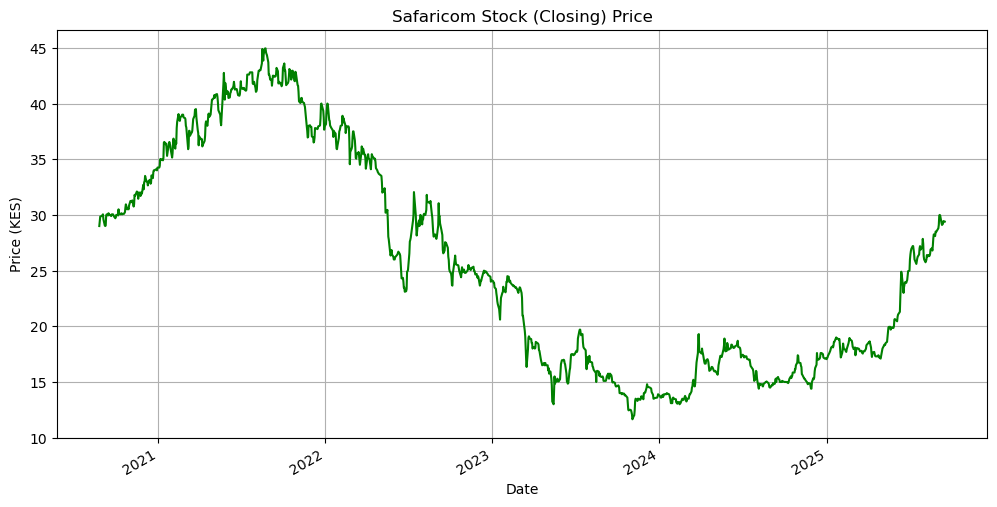

In [23]:
# Plot adjusted stock price
safcom['Last Price'].plot(figsize=(12,6), title='Safaricom Stock (Closing) Price', color='green', grid=True)
plt.xlabel('Date')
plt.ylabel('Price (KES)')
plt.show();

The trendline shows a period of surge in price between mid 2020 to mid 2021 before the share trended down continuously and hitting its minimum towards the end of 2024 before bouncing back with consistent growth from then up till now.

There seems to be a drastic drop in mid 2022 that breaks the general trend and should be investigated further in this analysis. Visually, it illustrates the biggest price swing period of the entire epoch under study.

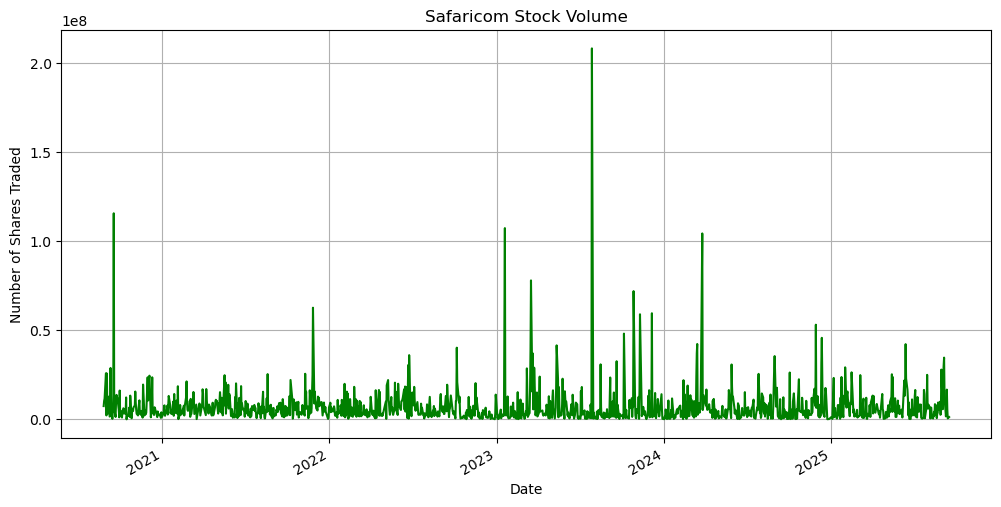

In [24]:
# Plotting raw safaricom stock price
safcom['Volume'].plot(figsize=(12,6), title='Safaricom Stock Volume', color='green', grid=True)
plt.xlabel('Date')
plt.ylabel('Number of Shares Traded')
plt.show()

The volume visualization displays no apparent trend, however, it should be noted that there seems to several periods with distinct surges in volume (especially in 2023) of stock traded and this will be investigated as it could provide evidence of distinct markets shifts.

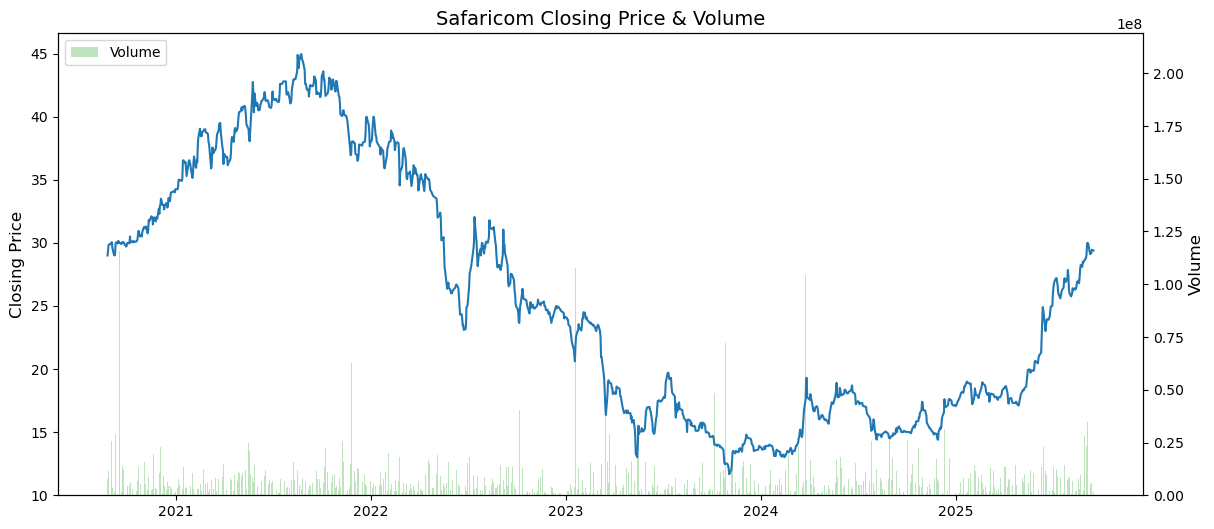

In [25]:
# Plot stock price & volume in the same figure
plt.figure(figsize=(14, 6))

ax1 = plt.gca()
ax1.plot(safcom.index, safcom['Last Price'], label='Closing Price', linewidth=1.5, color='tab:blue')
ax1.set_ylabel("Closing Price", fontsize=12)

ax2 = ax1.twinx()
ax2.bar(safcom.index, safcom['Volume'], color='tab:green', alpha=0.3, label='Volume')
ax2.set_ylabel("Volume", fontsize=12)

plt.title("Safaricom Closing Price & Volume", fontsize=14)
plt.legend(loc='upper left')
plt.show()

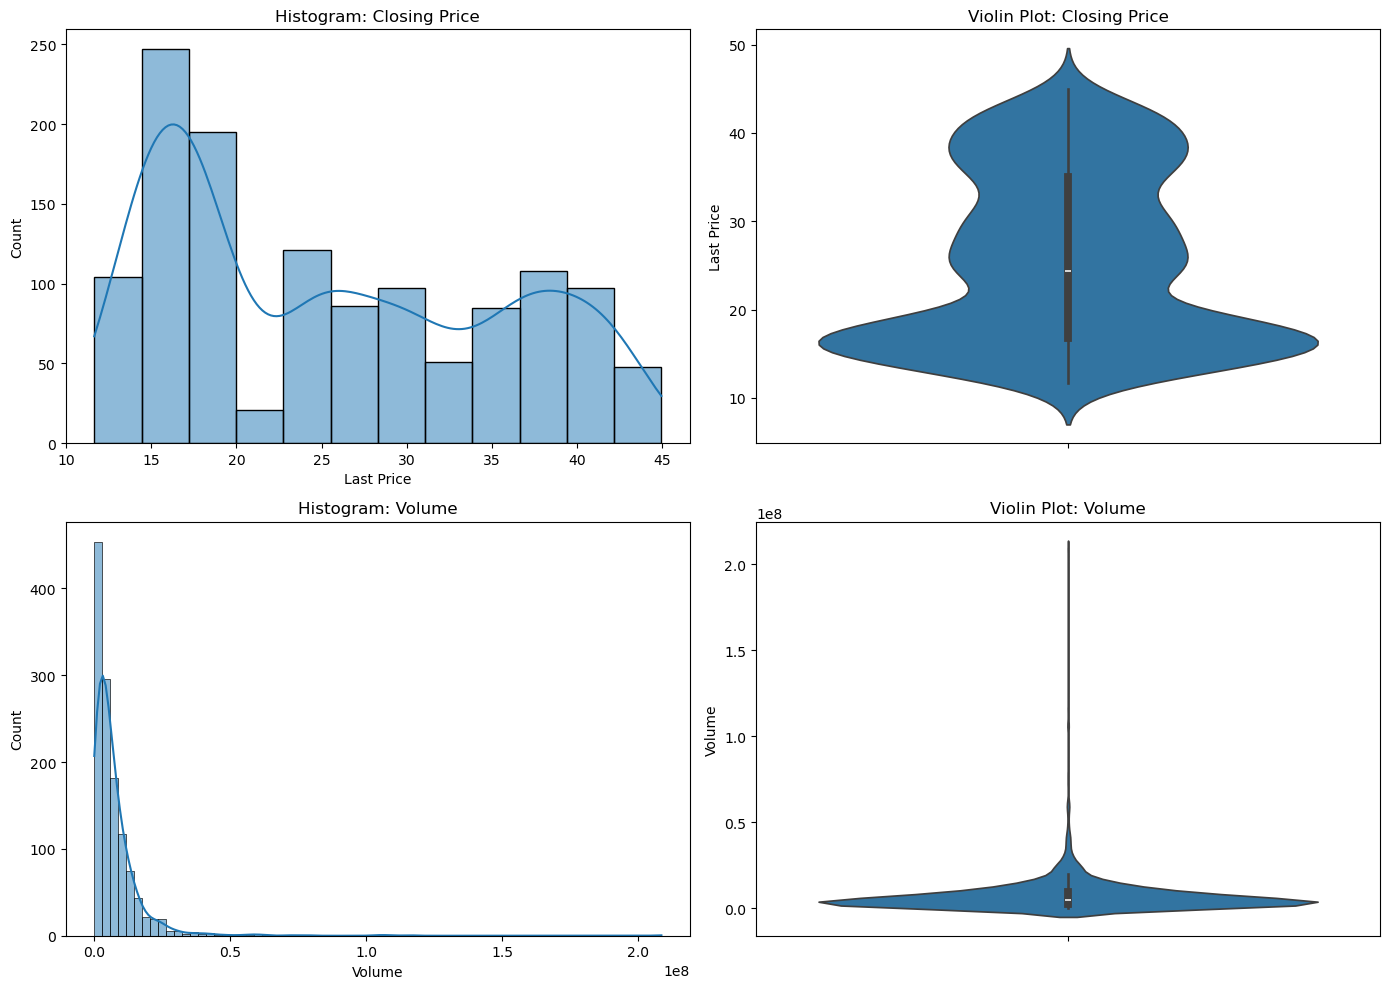

In [26]:
# Histograms + Box/Violin Plots for closing price as well as volume
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Histogram: Closing Price
sns.histplot(safcom['Last Price'], kde=True, ax=axes[0, 0])
axes[0, 0].set_title("Histogram: Closing Price")

# Box/Violin: Closing Price
sns.violinplot(y=safcom['Last Price'], ax=axes[0, 1])
axes[0, 1].set_title("Violin Plot: Closing Price")

# Histogram: Volume
sns.histplot(safcom['Volume'], kde=True, ax=axes[1, 0])
axes[1, 0].set_title("Histogram: Volume")

# Box/Violin: Volume
sns.violinplot(y=safcom['Volume'], ax=axes[1, 1])
axes[1, 1].set_title("Violin Plot: Volume")

plt.tight_layout()
plt.show()

From the above visualizations, we can make the following conclusions:

- Safaricom stock's closing price displays multimodal characteristics with at least 3 distcinct gaussian distributions present

- Safaricom stock's volume traded is highly rightly skewed with a slight mutimodal component.

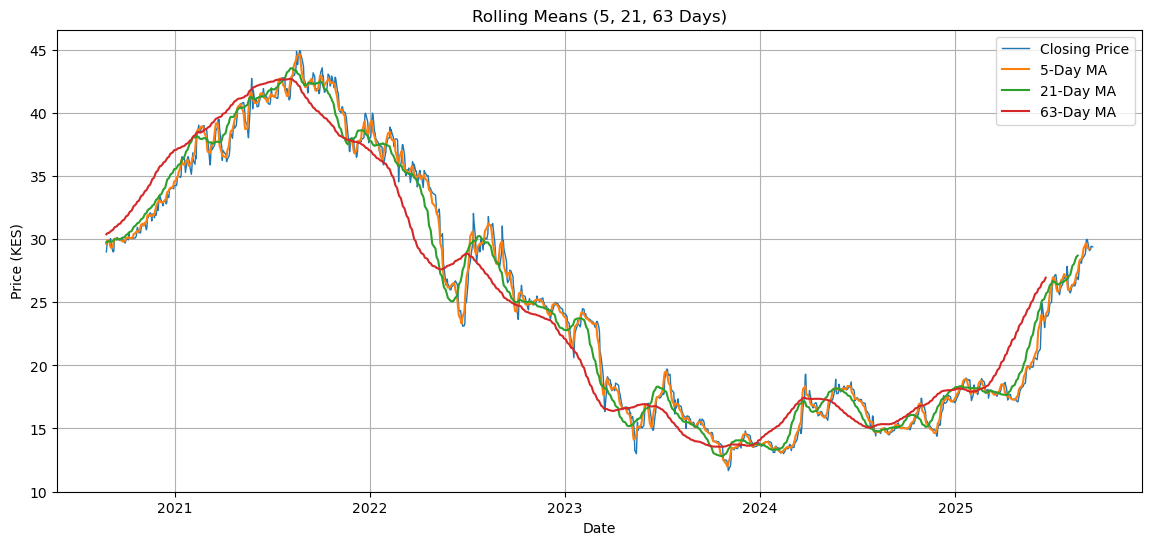

In [27]:
# 4. Rolling Means (5, 21, 63 Days)
safcom['MA_5'] = safcom['Last Price'].rolling(5).mean()
safcom['MA_21'] = safcom['Last Price'].rolling(21).mean()
safcom['MA_63'] = safcom['Last Price'].rolling(63).mean()

plt.figure(figsize=(14, 6))
plt.plot(safcom['Last Price'], label='Closing Price', linewidth=1)
plt.plot(safcom['MA_5'], label='5-Day MA')
plt.plot(safcom['MA_21'], label='21-Day MA')
plt.plot(safcom['MA_63'], label='63-Day MA')
plt.legend()
plt.grid()
plt.xlabel("Date")
plt.ylabel("Price (KES)")
plt.title("Rolling Means (5, 21, 63 Days)")
plt.show()

Before 2024 market switched between bullish and bearish, however, since the upturn (in 2024) the sfaricom share closing price has been predominantly bullish i.e. on an upward trend except for a notable bearish market run spanning start to mid 2024: when observed over a 63 tradind day rolling period (approx. every quarter).

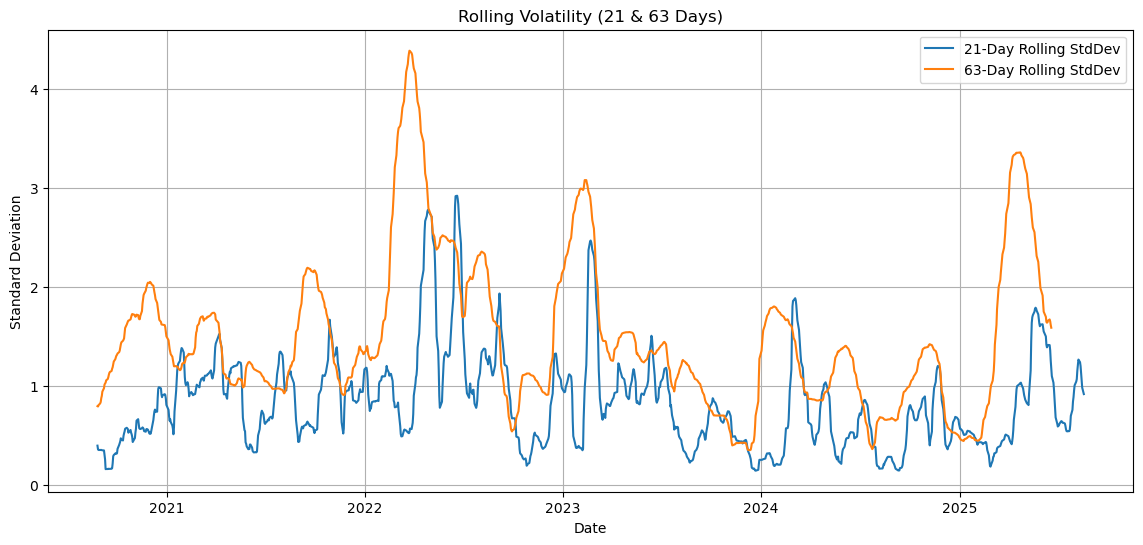

In [28]:
# -----------------------------------------------------------
# 5. Rolling Standard Deviation (21 & 63)
# -----------------------------------------------------------
safcom['STD_21'] = safcom['Last Price'].rolling(21).std()
safcom['STD_63'] = safcom['Last Price'].rolling(63).std()

plt.figure(figsize=(14, 6))
plt.plot(safcom['STD_21'], label='21-Day Rolling StdDev')
plt.plot(safcom['STD_63'], label='63-Day Rolling StdDev')
plt.legend()
plt.grid()
plt.xlabel("Date")
plt.ylabel("Standard Deviation")
plt.title("Rolling Volatility (21 & 63 Days)")
plt.show()

**{Interpret Above}**

## Returns Analysis

In [29]:
# Calculate simple returns
safcom['Simple Return'] = safcom['Last Price'].pct_change()

In [30]:
# Calculate log returns
safcom['Log Return'] = np.log(safcom['Last Price'] / safcom['Last Price'].shift(1))

In [31]:
# Display basic statistics for returns
return_stats = safcom[['Simple Return', 'Log Return']].describe()

In [32]:
print(return_stats)

       Simple Return   Log Return
count    1259.000000  1259.000000
mean        0.000154    -0.000011
std         0.018124     0.018165
min        -0.090909    -0.095310
25%        -0.007461    -0.007489
50%         0.000000     0.000000
75%         0.007866     0.007835
max         0.109434     0.103850


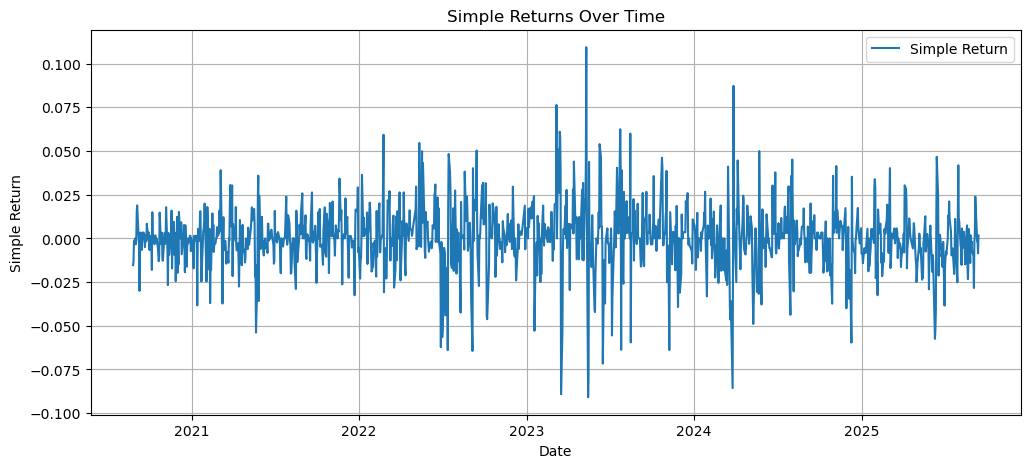

In [33]:
plt.figure(figsize=(12, 5))
plt.plot(safcom['Simple Return'].dropna(), label='Simple Return')
plt.legend()
plt.grid()
plt.xlabel("Date")
plt.ylabel("Simple Return")
plt.title("Simple Returns Over Time")
plt.show()

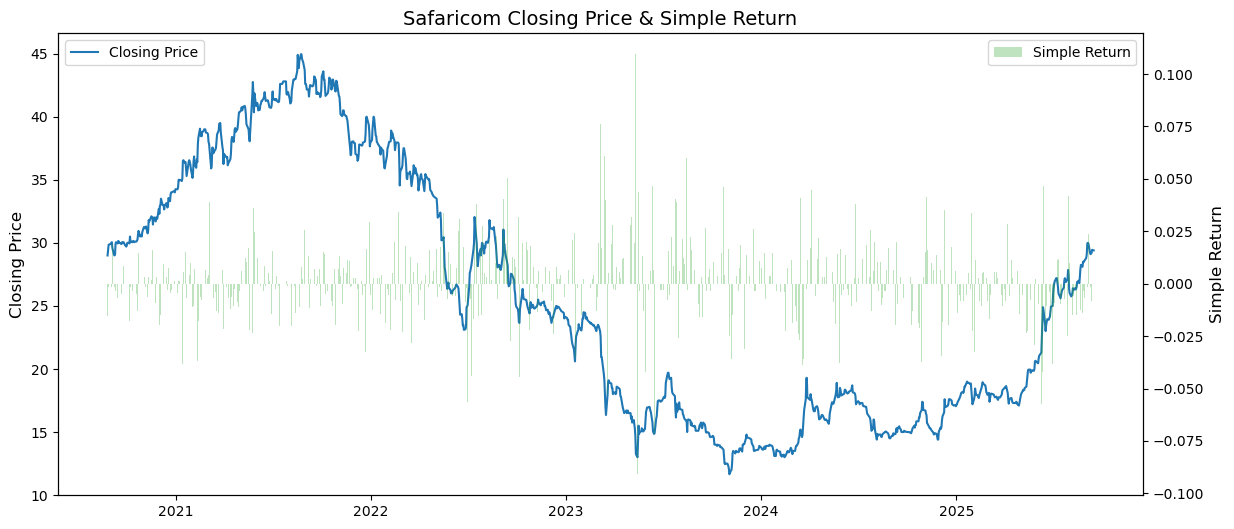

In [44]:
# Plot stock price & simple return in the same figure
plt.figure(figsize=(14, 6))

ax1 = plt.gca()
ax1.plot(safcom.index, safcom['Last Price'], label='Closing Price', linewidth=1.5, color='tab:blue')
ax1.set_ylabel("Closing Price", fontsize=12)
ax1.legend(loc='upper left')

ax2 = ax1.twinx()
ax2.bar(safcom.index, safcom['Simple Return'], color='tab:green', alpha=0.3, linewidth=1.0, label='Simple Return')
ax2.set_ylabel("Simple Return", fontsize=12)
ax2.legend(loc='upper right')

plt.title("Safaricom Closing Price & Simple Return", fontsize=14)
plt.show()

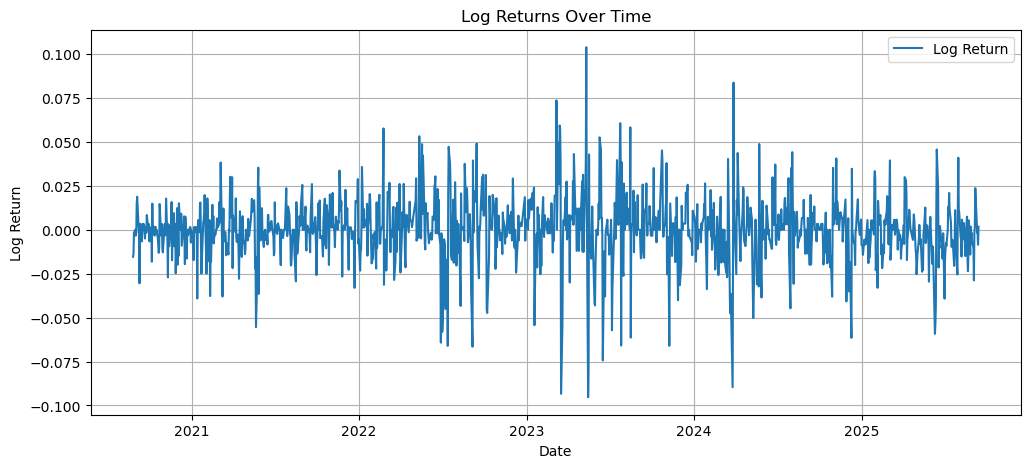

In [34]:
plt.figure(figsize=(12, 5))
plt.plot(safcom['Log Return'].dropna(), label='Log Return')
plt.legend()
plt.grid()
plt.xlabel("Date")
plt.ylabel("Log Return")
plt.title("Log Returns Over Time")
plt.show()

In [54]:
safcom_log_ret['STD_21'] = safcom['Log Return'].rolling(21).std()
safcom_log_ret['STD_63'] = safcom['Log Return'].rolling(63).std()

plt.figure(figsize=(14, 6))
plt.plot(safcom_log_ret['STD_21'], label='21-Day Rolling StdDev')
plt.plot(safcom_log_ret['STD_63'], label='63-Day Rolling StdDev')
plt.legend()
plt.grid()
plt.xlabel("Date")
plt.ylabel("Standard Deviation")
plt.title("Rolling Volatility of Log Returns (21 & 63 Days)")
plt.show()

NameError: name 'safcom_log_ret' is not defined

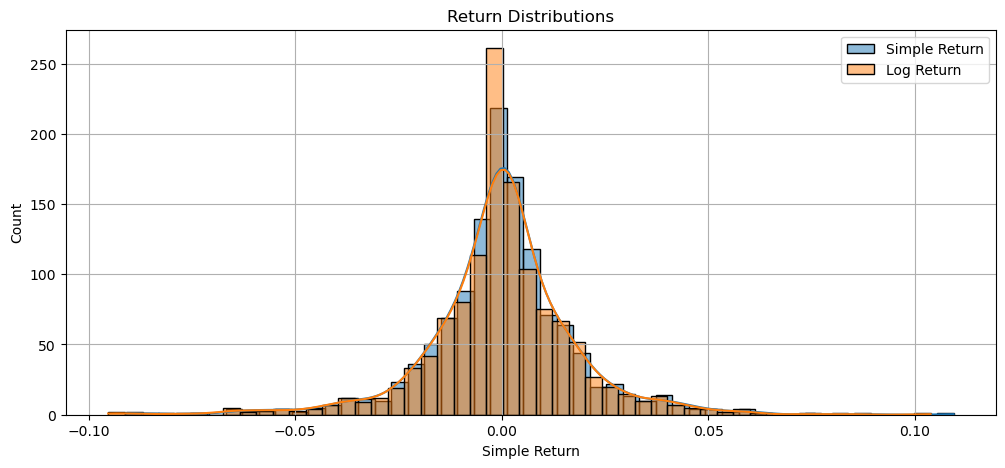

In [ ]:
# Visualize return distributions
plt.figure(figsize=(12, 5))
sns.histplot(safcom['Simple Return'].dropna(), bins=50, kde=True, label='Simple Return')
sns.histplot(safcom['Log Return'].dropna(), bins=50, kde=True, label='Log Return')
plt.legend()
plt.title("Return Distributions")
plt.grid()
plt.show()

The distribution of absolute and log returns seems normal with the log return showing a slight right shift.

While Safaricom’s share price distribution is skewed and multimodal due to structural regime shifts over time, its log returns exhibit near-normal behavior with slight positive skew. This indicates that daily price movements are largely stochastic and mean-reverting, while long-term price levels reflect regime accumulation rather than continuous drift.

...which translates to...

When we look at Safaricom’s day-to-day price changes, they follow a fairly stable and predictable pattern, with small movements most of the time and slightly more frequent upside gains than downside losses. This is different from the share price itself, which appears uneven over the years because it reflects major events and long-term shifts in the company and the economy.

In simple terms, short-term price movements tend to fluctuate around a normal level, while the long-term share price changes in steps as new phases or “regimes” emerge. This means daily price changes are mostly random and balanced, but the overall share price level evolves as the company goes through different growth and adjustment periods.

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Function to perform ADF test
def adf_test(series, series_name):
    result = adfuller(series.dropna())
    print(f'ADF Statistic for {series_name}: {result[0]}')
    print(f'p-value for {series_name}: {result[1]}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value}')
    print('\n')

# Perform ADF test on simple and log returns
adf_test(safcom['Simple Return'], 'Simple Return')
adf_test(safcom['Log Return'], 'Log Return')


ADF Statistic for Simple Return: -23.06088623976628
p-value for Simple Return: 0.0
Critical Values:
	1%: -3.4355464009607255
	5%: -2.8638347524449888
	10%: -2.5679917506718044


ADF Statistic for Log Return: -23.039150456618433
p-value for Log Return: 0.0
Critical Values:
	1%: -3.4355464009607255
	5%: -2.8638347524449888
	10%: -2.5679917506718044




P-values of 0.0 (theshold: p <= 0.05) and ADF statistics of -23 (which well exceeds the critcal  values at the 1% threshold i.e. -3.4355)in both cases show a strong indication that returns are stationary.
The share price evolves in phases, but daily price changes do not accumulate momentum on their own

<Figure size 1200x500 with 0 Axes>

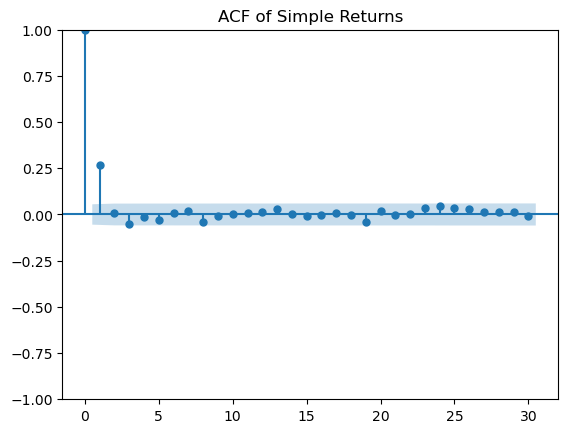

<Figure size 1200x500 with 0 Axes>

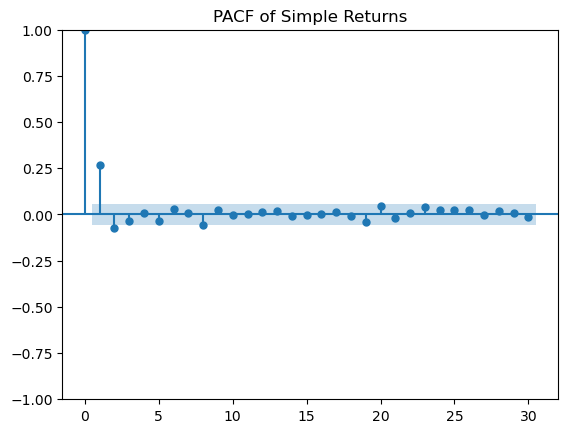

<Figure size 1200x500 with 0 Axes>

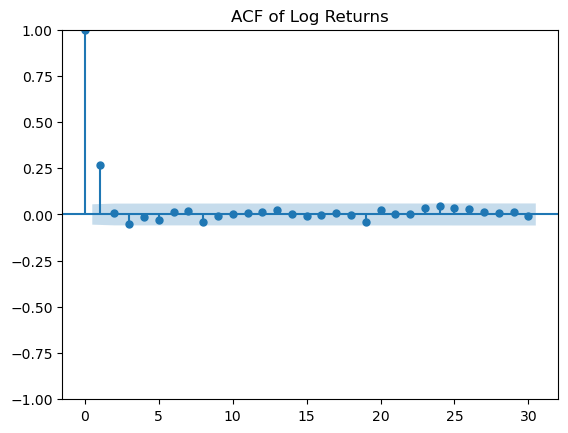

<Figure size 1200x500 with 0 Axes>

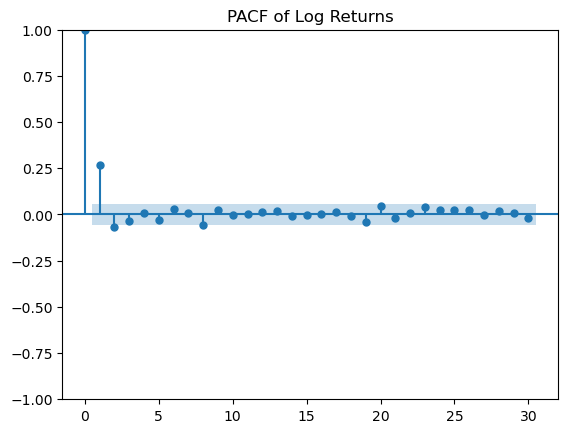

In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Plot ACF and PACF for simple returns
plt.figure(figsize=(12, 5))
plot_acf(safcom['Simple Return'].dropna(), lags=30)
plt.title('ACF of Simple Returns')
plt.show()

plt.figure(figsize=(12, 5))
plot_pacf(safcom['Simple Return'].dropna(), lags=30)
plt.title('PACF of Simple Returns')
plt.show()

# Repeat for log returns
plt.figure(figsize=(12, 5))
plot_acf(safcom['Log Return'].dropna(), lags=30)
plt.title('ACF of Log Returns')
plt.show()

plt.figure(figsize=(12, 5))
plot_pacf(safcom['Log Return'].dropna(), lags=30)
plt.title('PACF of Log Returns')
plt.show()


In all the above acf & pacf plots for simple and log returns, we can observe that only one strays out of the 95% confidence bands. This means that only 1 lag is significant hence weak short term dependence i.e. the market remembers yesterday and ever so sligtly beyond which past returns add no meaning ful predictive power.

This is an indication that he market prices in new information quickly, leaving little predictable structure in returns.

--- OR ---

We checked whether Safaricom’s daily returns depend on earlier days. The results show that only the immediately previous day has a very small influence, and beyond that, past price changes don’t meaningfully affect future ones. This tells us that short-term price movements are largely unpredictable and that the market adjusts quickly to new information.

In [61]:
# Cell 1: imports & helper functions
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.graphics.gofplots import qqplot
from statsmodels.stats.stattools import jarque_bera
from scipy import stats

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# small helper for nicely printing test results
def print_adf(series, name="Series"):
    res = adfuller(series.dropna(), autolag='AIC')
    print(f"ADF test for {name}")
    print(f"  ADF statistic : {res[0]:.6f}")
    print(f"  p-value       : {res[1]:.6f}")
    for k, v in res[4].items():
        print(f"   critical {k}: {v:.6f}")
    print("  usedlag:", res[2], "nobs:", res[3])
    print()

def print_kpss(series, name="Series"):
    res = kpss(series.dropna(), regression='c', nlags='auto')
    print(f"KPSS test for {name}")
    print(f"  KPSS statistic: {res[0]:.6f}")
    print(f"  p-value       : {res[1]:.6f}")
    for k, v in res[3].items():
        print(f"   critical {k}: {v:.6f}")
    print("  lags used:", res[2])
    print()

def print_jb(series, name="Series"):
    stat, pval, skew, kurt = jarque_bera(series.dropna())
    print(f"Jarque–Bera test for {name}")
    print(f"  JB statistic : {stat:.6f}")
    print(f"  p-value      : {pval:.6f}")
    print(f"  skewness     : {skew:.6f}")
    print(f"  kurtosis     : {kurt:.6f}")
    print()


In [ ]:
# Cell 2: stationarity tests
# ADF & KPSS for Log Return
print_adf(safcom['Log Return'], name='Log Return')
print_kpss(safcom['Log Return'], name='Log Return')

# (optional) ADF & KPSS for Simple Return
print_adf(safcom['Simple Return'], name='Simple Return')
print_kpss(safcom['Simple Return'], name='Simple Return')


ADF test for Log Return
  ADF statistic : -23.039150
  p-value       : 0.000000
   critical 1%: -3.435546
   critical 5%: -2.863835
   critical 10%: -2.567992
  usedlag: 1 nobs: 1261

KPSS test for Log Return
  KPSS statistic: 0.340842
  p-value       : 0.100000
   critical 10%: 0.347000
   critical 5%: 0.463000
   critical 2.5%: 0.574000
   critical 1%: 0.739000
  lags used: 2

ADF test for Simple Return
  ADF statistic : -23.060886
  p-value       : 0.000000
   critical 1%: -3.435546
   critical 5%: -2.863835
   critical 10%: -2.567992
  usedlag: 1 nobs: 1261

KPSS test for Simple Return
  KPSS statistic: 0.328947
  p-value       : 0.100000
   critical 10%: 0.347000
   critical 5%: 0.463000
   critical 2.5%: 0.574000
   critical 1%: 0.739000
  lags used: 2



In [ ]:
# Cell 3: moments and normality tests
for col in ['Simple Return', 'Log Return']:
    s = safcom[col].dropna()
    print(f"=== {col} ===")
    print(f"count: {s.count()}, mean: {s.mean():.8f}, std: {s.std():.8f}")
    print(f"skewness: {s.skew():.6f}, kurtosis: {s.kurtosis():.6f}")  # fisher's (excess) kurtosis
    print_jb(s, name=col)


=== Simple Return ===
count: 1263, mean: 0.00017579, std: 0.01821549
skewness: 0.492394, kurtosis: 4.727851
Jarque–Bera test for Simple Return
  JB statistic : 1215.582675
  p-value      : 0.000000
  skewness     : 0.491809
  kurtosis     : 7.704408

=== Log Return ===
count: 1263, mean: 0.00001085, std: 0.01815081
skewness: 0.316961, kurtosis: 4.554977
Jarque–Bera test for Log Return
  JB statistic : 1102.067618
  p-value      : 0.000000
  skewness     : 0.316585
  kurtosis     : 7.532218



<Figure size 600x600 with 0 Axes>

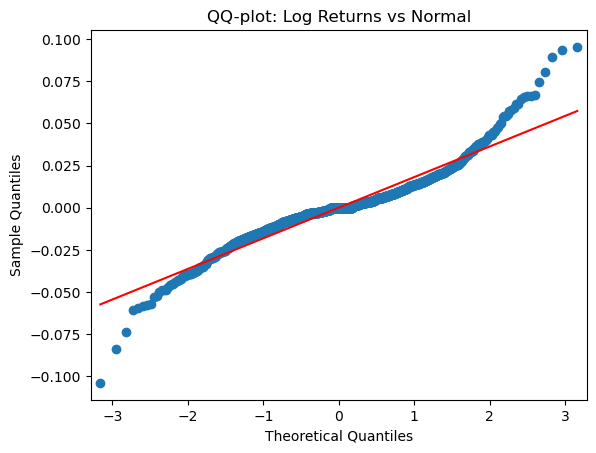

In [ ]:
# Cell 4: QQ-plot (Log Return)
plt.figure(figsize=(6,6))
qqplot(safcom['Log Return'].dropna(), line='s')
plt.title('QQ-plot: Log Returns vs Normal')
plt.show()

An S-shape along the diagonal means:

The center of the distribution behaves very close to normal
The tails deviate from normality especially, more on the left than the right
Large positive returns occur more often than expected under normality, furthermore, upside shocks are more pronounced than downside ones

Specifically:
Middle quantiles ≈ diagonal → everyday market behavior is well-behaved
Ends curve away → extreme events occur more often than a normal model predicts

-- meaning --

When we compare Safaricom’s daily returns to a perfectly normal market, most days behave exactly as expected. However, very large price moves — especially positive ones — occur slightly more often than a normal model would predict. This means that while day-to-day behavior is stable, extreme market reactions are more common on the upside than on the downside.

<Figure size 1200x400 with 0 Axes>

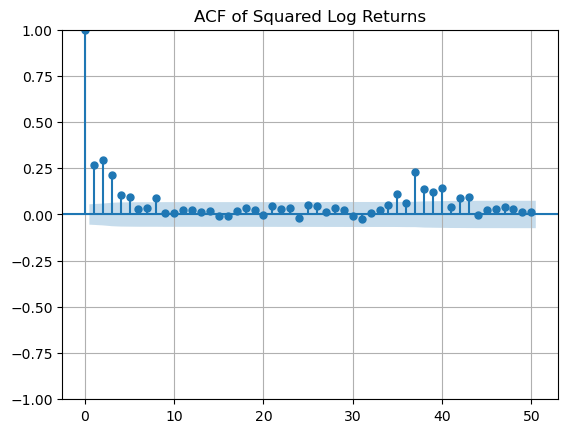

<Figure size 1200x400 with 0 Axes>

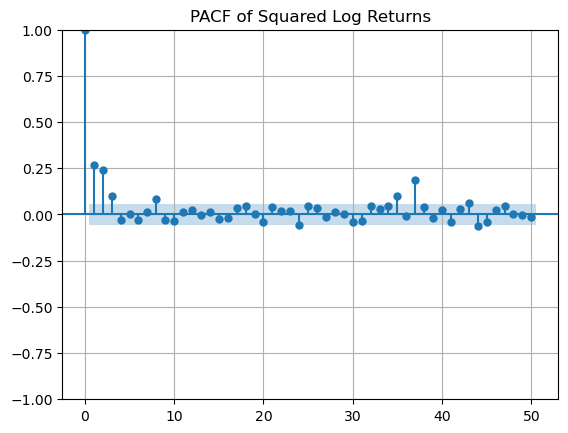

In [ ]:
# Cell 5: ACF/PACF for squared returns 
sq = (safcom['Log Return'].dropna())**2
absr = safcom['Log Return'].dropna().abs()

plt.figure(figsize=(12,4))
plot_acf(sq, lags=50, title='ACF of Squared Log Returns')
plt.grid()
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(sq, lags=50, title='PACF of Squared Log Returns')
plt.grid()
plt.show()

<Figure size 1200x400 with 0 Axes>

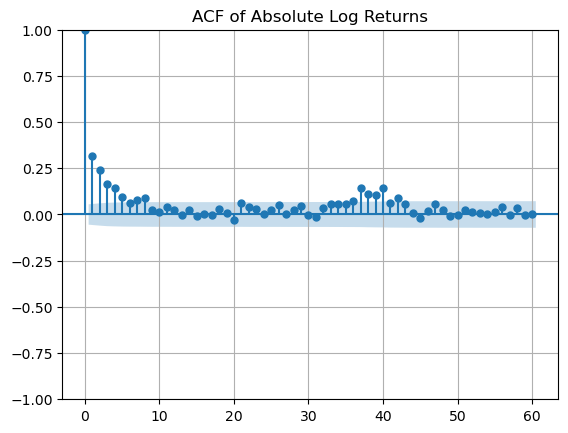

<Figure size 1200x400 with 0 Axes>

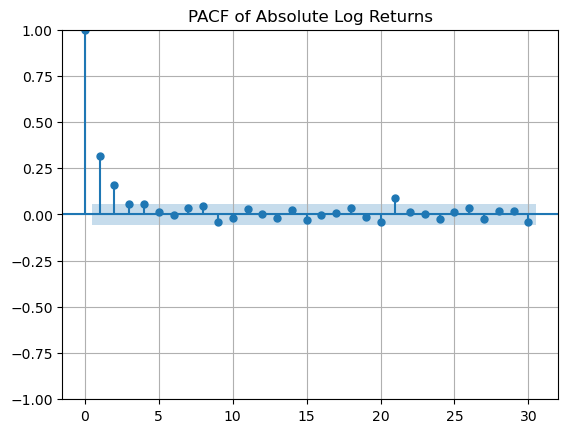

In [66]:
# ACF/PACF for absolute returns
plt.figure(figsize=(12,4))
plot_acf(absr, lags=60, title='ACF of Absolute Log Returns')
plt.grid()
plt.show()

plt.figure(figsize=(12,4))
plot_pacf(absr, lags=30, title='PACF of Absolute Log Returns')
plt.grid()
plt.show()

The following lag structure was observed was as shown:
**Absolute log returns**

ACF: 1–5, and clustered again at ~37–40
PACF: sparse but meaningful (2, 4, 22)

**Squared log returns**
ACF: 1–5, 8, and again ~35–40
PACF: 1–3, 8, 37

Interpretation:

*Short-term clustering (lags 1–5):*
- Volatility persists for about a trading week

*Medium-term memory (lag ~8):*
- Roughly bi-weekly reinforcement

*Longer-term seasonal echoes (lags ~35–40):*
- About 1.5–2 months

Likely linked to:
- Earnings cycles
- Policy/news digestion
- Institutional rebalancing

This tells you volatility has structure at multiple horizons, not randomness.

In [ ]:
# Cell 6: Ljung-Box (recommended)
from statsmodels.stats.diagnostic import acorr_ljungbox

# For returns
lb_ret = acorr_ljungbox(safcom['Log Return'].dropna(), lags=[10, 20, 30], return_df=True)
print("Ljung-Box test on Log Returns (lags 10,20,30):")
print(lb_ret)
print()

# For squared returns (volatility)
lb_sq = acorr_ljungbox((safcom['Log Return'].dropna()**2), lags=[10,20,30], return_df=True)
print("Ljung-Box test on Squared Log Returns (lags 10,20,30):")
print(lb_sq)


Ljung-Box test on Log Returns (lags 10,20,30):
       lb_stat     lb_pvalue
10   98.509933  1.082438e-16
20  102.660839  4.195199e-13
30  110.548006  3.742716e-11

Ljung-Box test on Squared Log Returns (lags 10,20,30):
       lb_stat     lb_pvalue
10  298.801934  2.785428e-58
20  303.745034  1.388339e-52
30  318.200145  6.705200e-50


Ljung-box test results of approximately 0 for log and squared log returns indicate there is statistically detectable dependence in returns however this is weak/ short-lived as illustrated by the ACF/PACF plots. Furthermore, volatility is strongly autocorrelated and highly predictable.

--- OR ---

While it’s difficult to consistently predict whether the share price will go up or down on a given day, it is much easier to predict periods of high and low risk. Large price movements tend to cluster together, meaning calm periods and volatile periods persist over time.

Year by Year Breakdown

In [ ]:
safcom['Year'] = safcom.index.year

In [ ]:
yearly_summary = safcom.groupby('Year').agg({
    'Last Price': ['mean', 'median', 'min', 'max', 'std'],
    'Volume': ['sum', 'mean']
})

yearly_summary


Last Price                                        Volume              
           mean  median    min    max       std           sum          mean
Year                                                                       
2020  31.206111  30.700  29.00  34.25  1.464502  7.554904e+08  8.394338e+06
2021  39.882143  40.350  34.25  44.95  2.519343  1.805778e+09  7.165787e+06
2022  30.134756  29.075  23.10  40.00  5.025576  1.556362e+09  6.326673e+06
2023  17.168145  16.300  11.65  24.50  3.419457  2.098195e+09  8.460465e+06
2024  15.711000  15.375  13.00  19.30  1.567929  1.777915e+09  7.111661e+06
2025  21.643539  19.025  17.10  30.00  4.253902  1.336440e+09  7.508091e+06

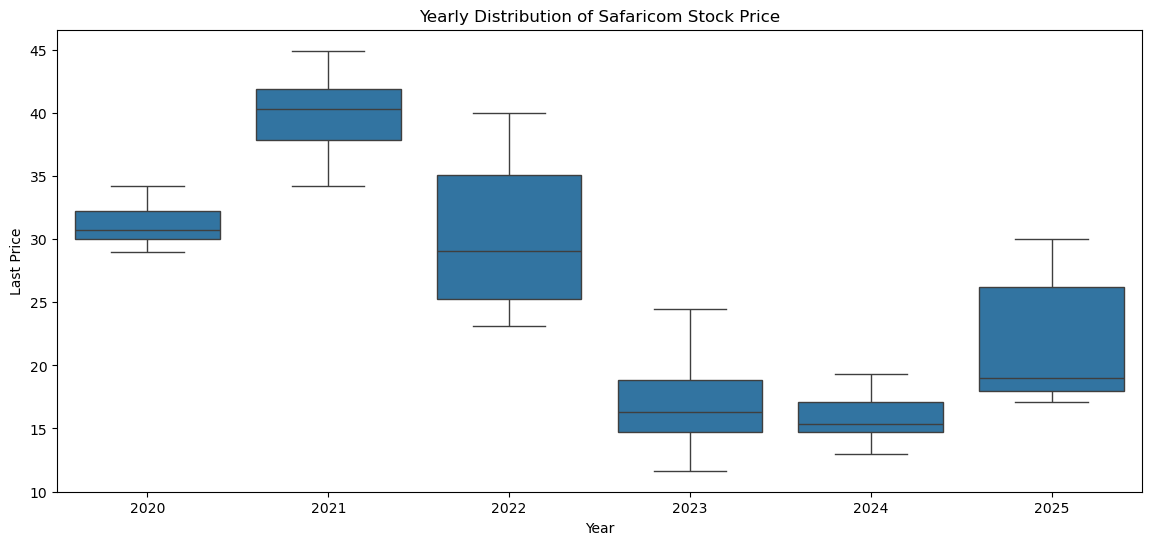

In [ ]:
plt.figure(figsize=(14, 6))
sns.boxplot(x='Year', y='Last Price', data=safcom)
plt.title("Yearly Distribution of Safaricom Stock Price")
plt.show()

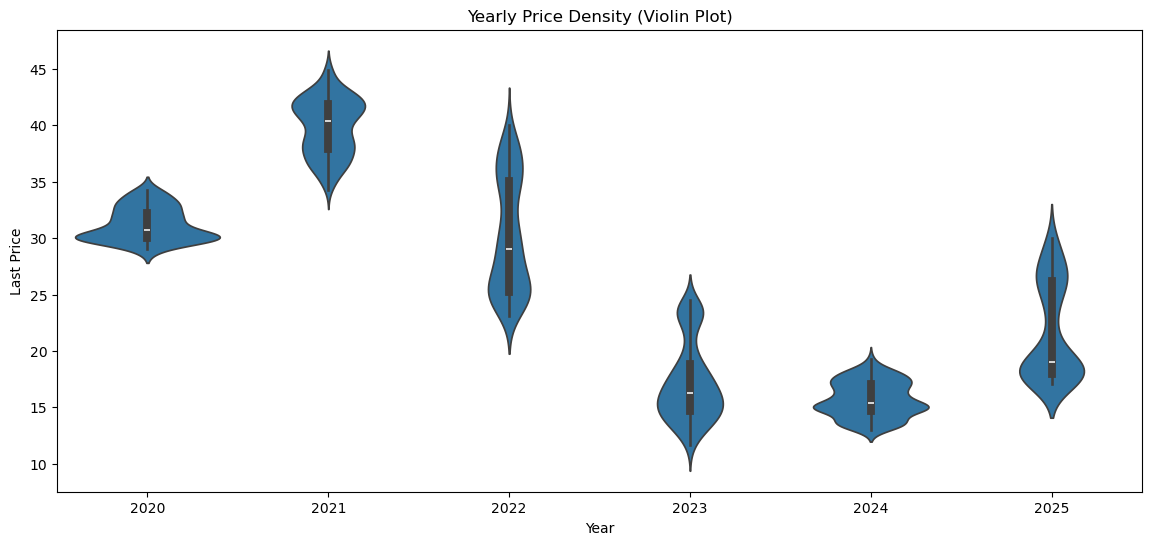

In [ ]:
plt.figure(figsize=(14, 6))
sns.violinplot(x='Year', y='Last Price', data=safcom)
plt.title("Yearly Price Density (Violin Plot)")
plt.show()

The year-by-year boxplots reveal distinct regime characteristics in Safaricom’s price behavior.
2022 and 2025 exhibit wide interquartile ranges, indicating elevated intra-year price dispersion and the presence of multiple valuation regimes.
In contrast, 2020 and 2024 display narrow interquartile ranges, suggesting price compression and rapid mean reversion.
Notably, the 2025 distribution is positively skewed, with a longer upper tail, signaling asymmetric upside movements and sustained bullish repricing during the year.

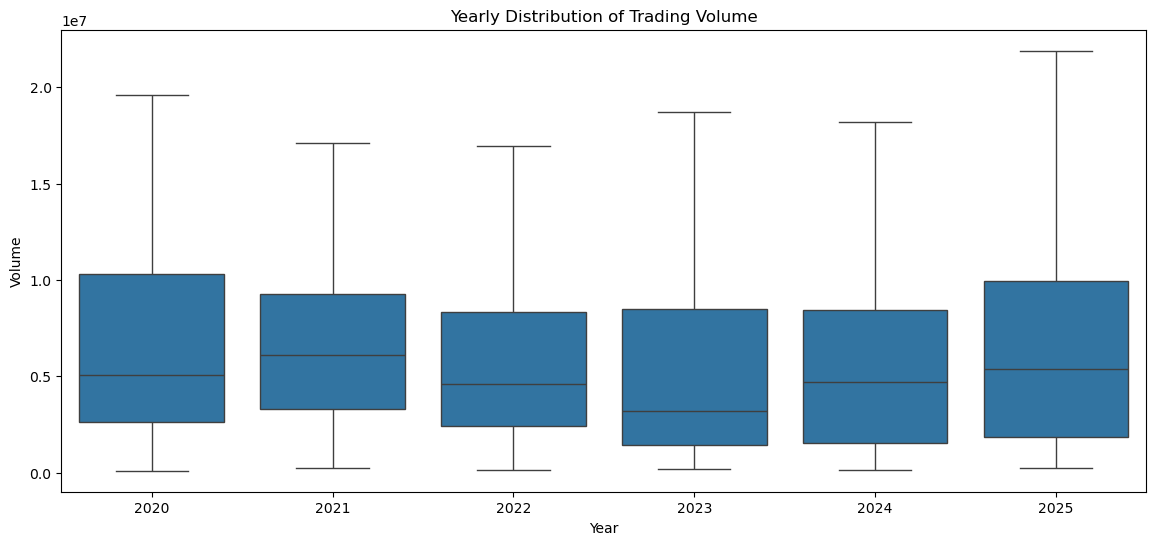

In [ ]:
plt.figure(figsize=(14, 6))
sns.boxplot(x='Year', y='Volume', data=safcom, showfliers=False)
plt.title("Yearly Distribution of Trading Volume")
plt.show()

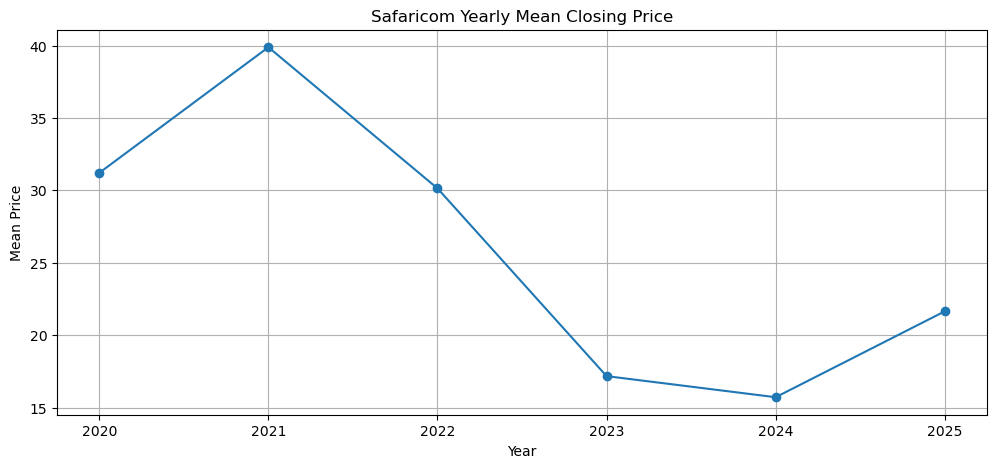

In [ ]:
yearly_means = safcom.groupby('Year')['Last Price'].mean()

plt.figure(figsize=(12, 5))
plt.plot(yearly_means.index, yearly_means.values, marker='o')
plt.title("Safaricom Yearly Mean Closing Price")
plt.xlabel("Year")
plt.ylabel("Mean Price")
plt.grid(True)
plt.show()


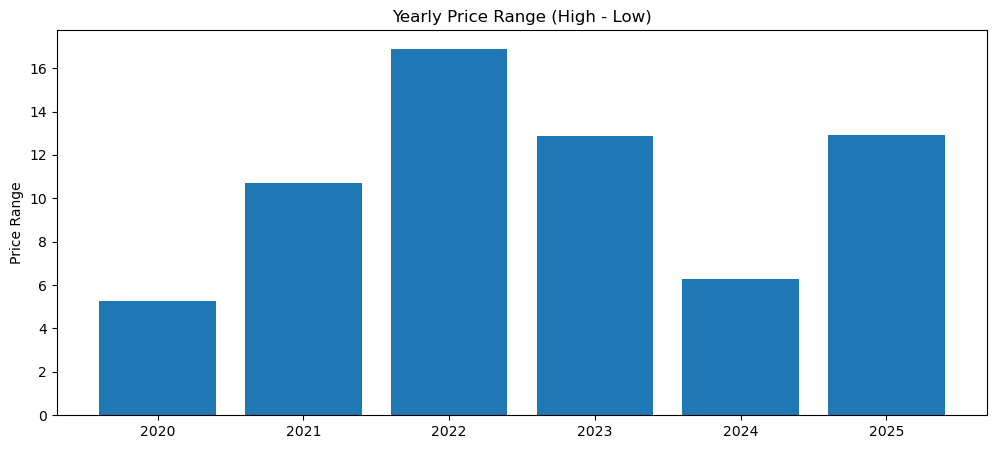

In [ ]:
yearly_range = safcom.groupby('Year')['Last Price'].agg(lambda x: x.max() - x.min())

plt.figure(figsize=(12, 5))
plt.bar(yearly_range.index, yearly_range.values)
plt.title("Yearly Price Range (High - Low)")
plt.ylabel("Price Range")
plt.show()

Decomposition

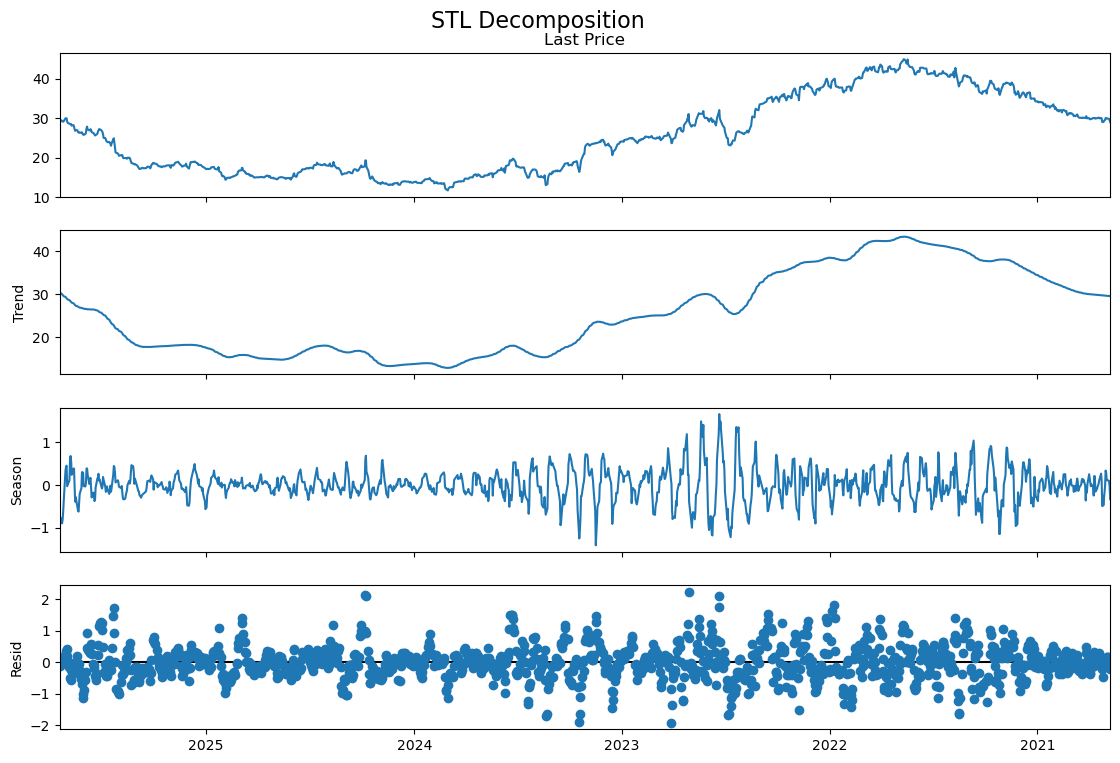

In [45]:
# Cell 1: STL decomposition
from statsmodels.tsa.seasonal import STL

# STL usually requires no missing values – use adjusted series (carried forward)
price_series = safcom['Last Price'].dropna()

stl = STL(price_series, period=21)  # approx 1 trading month
res = stl.fit()

fig = res.plot()
fig.set_size_inches(12, 8)
plt.suptitle("STL Decomposition", fontsize=16)
plt.show()

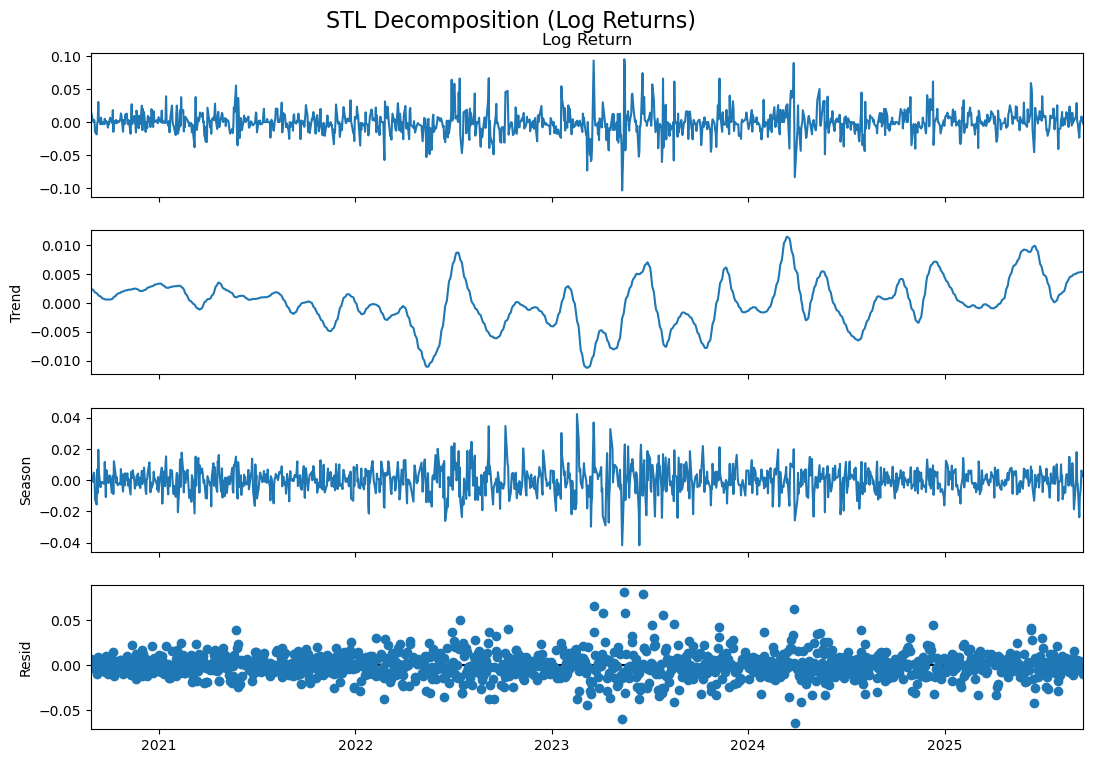

In [ ]:
# Cell 2: STL on Log Returns
logret = safcom['Log Return'].dropna()

stl_ret = STL(logret, period=21)
res_ret = stl_ret.fit()

fig = res_ret.plot()
fig.set_size_inches(12, 8)
plt.suptitle("STL Decomposition (Log Returns)", fontsize=16)
plt.show()

Opportunity in Safaricom comes from identifying long-term regime shifts in price.

Risk comes from time-varying volatility, not from directional uncertainty.

Or more plainly:

You cannot reliably predict tomorrow’s return

You can identify when risk is rising or falling

Long-term gains come from being positioned during favorable regimes, not from frequent trading

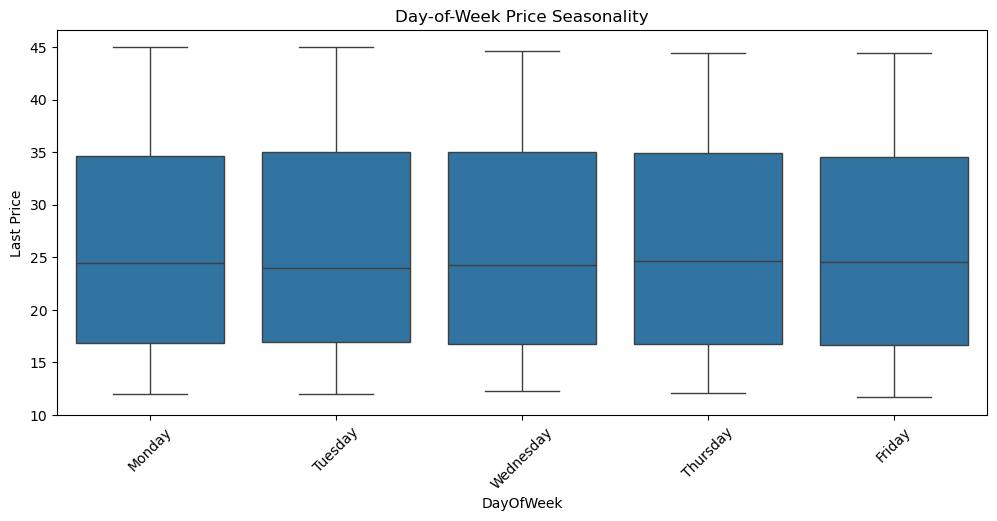

In [ ]:
# Cell 3: Day-of-week seasonality
safcom['DayOfWeek'] = safcom.index.day_name()

plt.figure(figsize=(12, 5))
sns.boxplot(x='DayOfWeek', y='Last Price', data=safcom,
            order=['Monday','Tuesday','Wednesday','Thursday','Friday'])
plt.title("Day-of-Week Price Seasonality")
plt.xticks(rotation=45)
plt.show()

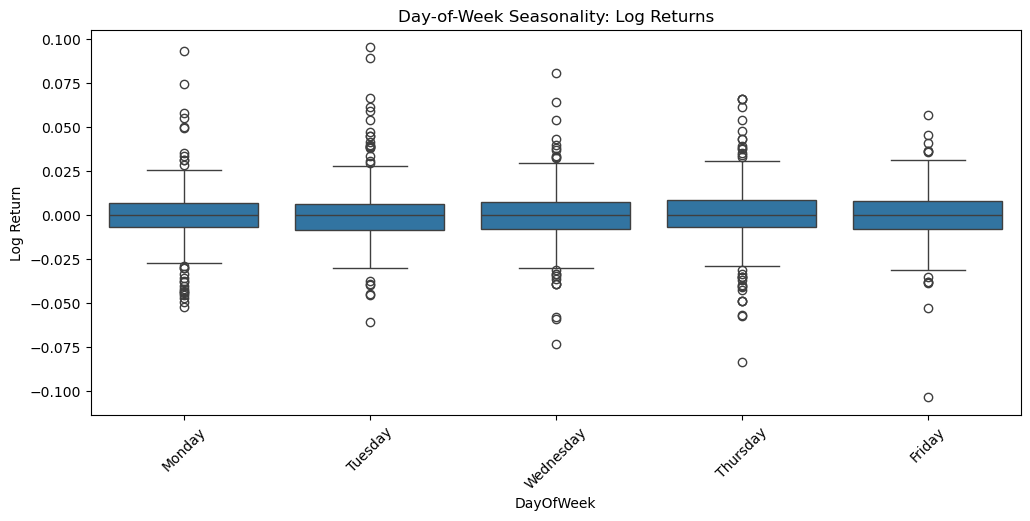

In [ ]:
# Cell 4: Day-of-week seasonality for returns
plt.figure(figsize=(12, 5))
sns.boxplot(x='DayOfWeek', y='Log Return', data=safcom,
            order=['Monday','Tuesday','Wednesday','Thursday','Friday'])
plt.title("Day-of-Week Seasonality: Log Returns")
plt.xticks(rotation=45)
plt.show()

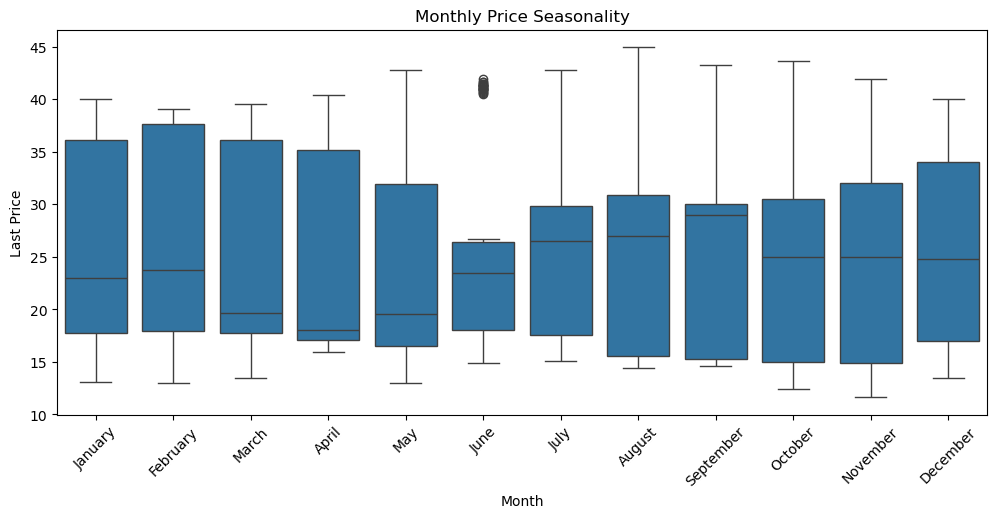

In [ ]:
# Cell 5: Month seasonality (Price)
safcom['Month'] = safcom.index.month_name()

plt.figure(figsize=(12, 5))
sns.boxplot(x='Month', y='Last Price', data=safcom,
            order=['January','February','March','April','May','June',
                   'July','August','September','October','November','December'])
plt.title("Monthly Price Seasonality")
plt.xticks(rotation=45)
plt.show()

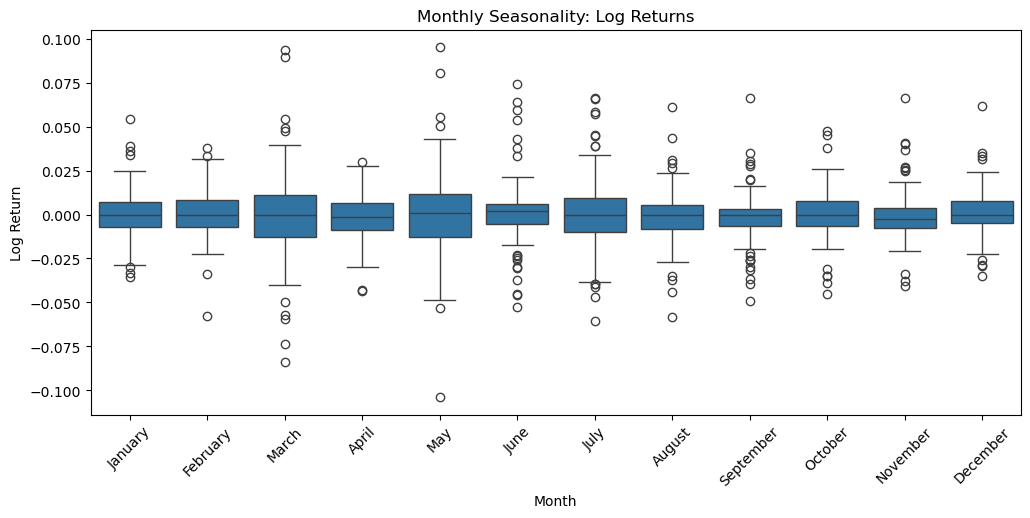

In [ ]:
# Cell 6: Month seasonality (Returns)
plt.figure(figsize=(12, 5))
sns.boxplot(x='Month', y='Log Return', data=safcom,
            order=['January','February','March','April','May','June',
                   'July','August','September','October','November','December'])
plt.title("Monthly Seasonality: Log Returns")
plt.xticks(rotation=45)
plt.show()

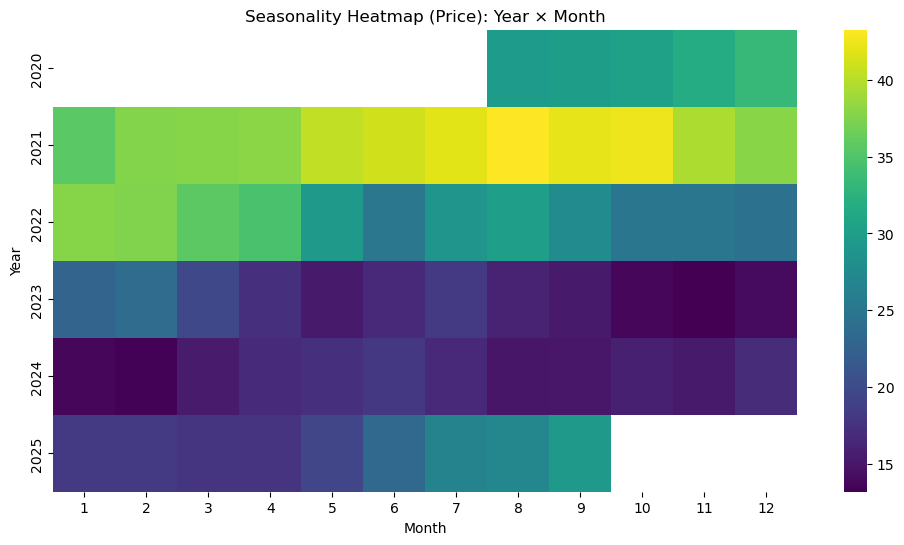

In [ ]:
# Cell 7: Monthly average price heatmap
pivot = safcom.pivot_table(values='Last Price',
                               index=safcom.index.year,
                               columns=safcom.index.month,
                               aggfunc='mean')

plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=False, cmap='viridis')
plt.title("Seasonality Heatmap (Price): Year × Month")
plt.xlabel("Month")
plt.ylabel("Year")
plt.show()

<Figure size 1200x500 with 0 Axes>

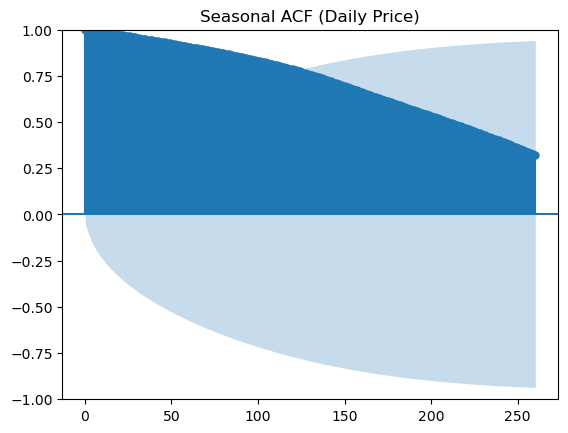

In [ ]:
# Cell 8: Seasonal ACF checks
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12,5))
plot_acf(safcom['Last Price'].dropna(), lags=260)
plt.title("Seasonal ACF (Daily Price)")
plt.show()

Correlation & Rolling Correlation Analysis

In [ ]:
# Cell 2: prepare aligned series
data = safcom[['Last Price', 'Volume', 'Simple Return', 'Log Return']].copy()
data = data.dropna()  # drop rows with any NA in core cols
# quick sanity check
print("Start / end:", data.index.min(), data.index.max())
data.head()

Start / end: 2020-08-27 00:00:00 2025-09-15 00:00:00


,Last Price,Volume,Simple Return,Log Return
Date,,,,
2020-08-27,29.45,10409989.0,0.015517,0.015398
2020-08-28,29.85,11730856.0,0.013582,0.013491
2020-08-31,29.90,25963512.0,0.001675,0.001674
2020-09-01,29.90,2291221.0,0.000000,0.000000
2020-09-02,30.00,25815286.0,0.003344,0.003339


Overall Pearson correlation matrix:


,Last Price,Volume,Simple Return,Log Return
Last Price,1.000000,-0.032797,0.018598,0.021381
Volume,-0.032797,1.000000,0.008065,0.003532
Simple Return,0.018598,0.008065,1.000000,0.999735
Log Return,0.021381,0.003532,0.999735,1.000000


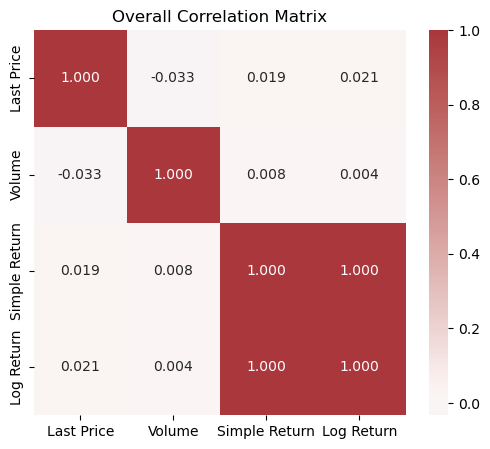

In [84]:
# Cell 3: overall correlation matrix
corr_overall = data[['Last Price', 'Volume', 'Simple Return', 'Log Return']].corr()
print("Overall Pearson correlation matrix:")
display(corr_overall)

# visual heatmap
plt.figure(figsize=(6,5))
sns.heatmap(corr_overall, annot=True, fmt=".3f", cmap='vlag', center=0)
plt.title("Overall Correlation Matrix")
plt.show()


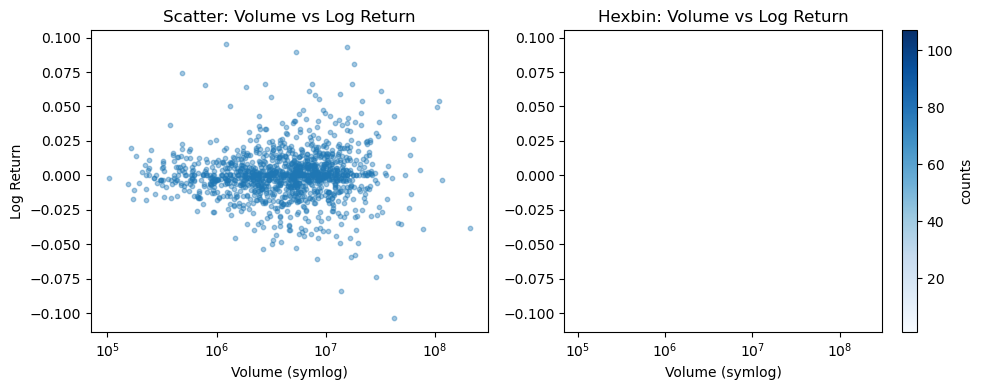

In [85]:
# Cell 4: scatter + hexbin and marginal kde for Log Return vs Volume
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.scatter(data['Volume'], data['Log Return'], alpha=0.4, s=10)
plt.xscale('symlog')  # volumes can be heavy-tailed; symlog helps visualization
plt.xlabel('Volume (symlog)')
plt.ylabel('Log Return')
plt.title('Scatter: Volume vs Log Return')

plt.subplot(1,2,2)
hb = plt.hexbin(data['Volume'], data['Log Return'], gridsize=50, cmap='Blues', mincnt=1)
plt.xscale('symlog')
plt.colorbar(hb, label='counts')
plt.xlabel('Volume (symlog)')
plt.title('Hexbin: Volume vs Log Return')

plt.tight_layout()
plt.show()

# Optional seaborn jointplot (slower but nice)
# sns.jointplot(x='Volume', y='Log Return', data=data.sample(min(len(data),2000)),
#               kind='hex', marginal_kws=dict(bins=30), height=6)
# plt.show()


,"Corr(LogRet,Volume)","Corr(LogRet,Price)"
Year,,
2020,0.105418,0.150417
2021,0.125781,0.057849
2022,-0.017735,0.048810
2023,-0.113709,0.022560
2024,0.125790,0.088447
2025,0.218158,0.089883


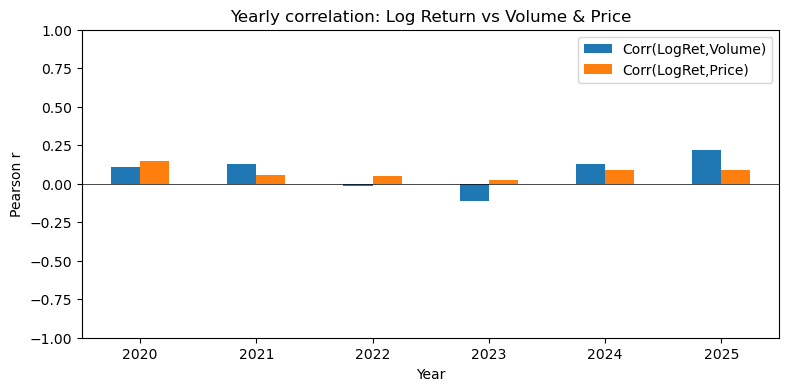

In [ ]:
# Cell 5: correlations by year
data['Year'] = data.index.year

def yearly_corr(df, cols):8
    out = []
    for y, g in df.groupby('Year'):
        c = g[cols].corr().loc[cols, cols]
        # we only want single value pairs; we'll extract specific ones below
        out.append((y, g[cols].corr().loc['Log Return','Volume'], g[cols].corr().loc['Log Return','Last Price']))
    return pd.DataFrame(out, columns=['Year','Corr(LogRet,Volume)','Corr(LogRet,Price)']).set_index('Year')

year_corr = yearly_corr(data, ['Log Return','Volume','Last Price'])
display(year_corr)

# quick plot
year_corr.plot(kind='bar', figsize=(9,4), rot=0)
plt.title('Yearly correlation: Log Return vs Volume & Price')
plt.ylabel('Pearson r')
plt.ylim(-1,1)
plt.axhline(0, color='k', linewidth=0.5)
plt.show()

In [87]:
# Cell 6: helper to compute rolling correlations for given windows
def rolling_corr(series_x, series_y, windows=[21,63,252]):
    df = pd.DataFrame(index=series_x.dropna().index)
    x = series_x.reindex(df.index).astype(float)
    y = series_y.reindex(df.index).astype(float)
    for w in windows:
        df[f'rolling_corr_{w}'] = x.rolling(window=w).corr(y)
    return df

# example usage (not run yet)
# rc = rolling_corr(data['Log Return'], data['Volume'], windows=[21,63,252])
# rc.head()

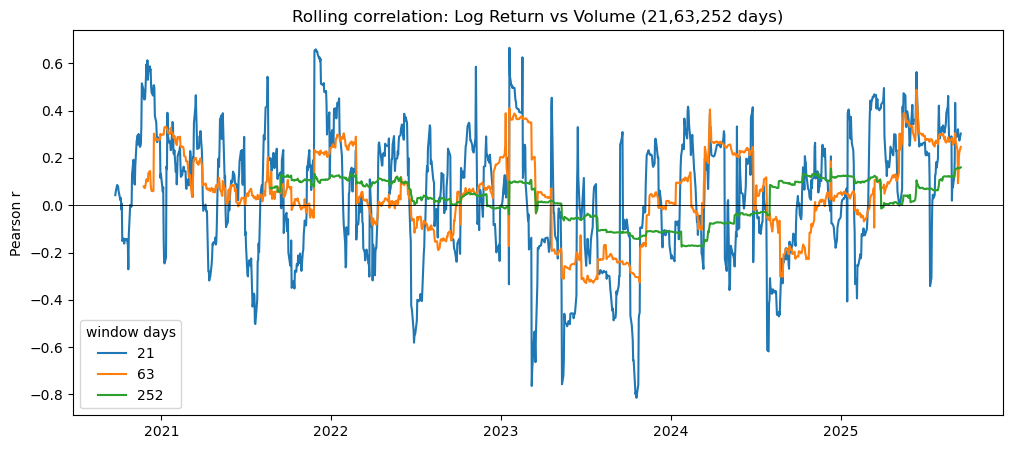

,count,mean,std,min,25%,50%,75%,max
rolling_corr_21,1243.0,0.043238,0.270044,-0.813882,-0.146791,0.066482,0.244736,0.665461
rolling_corr_63,1201.0,0.053704,0.176077,-0.328959,-0.048923,0.050987,0.204941,0.487828
rolling_corr_252,1012.0,0.024651,0.089366,-0.175121,-0.042825,0.041933,0.102060,0.160034


In [88]:
# Cell 7: rolling correlation Log Return vs Volume
rc_ret_vol = rolling_corr(data['Log Return'], data['Volume'], windows=[21,63,252])

plt.figure(figsize=(12,5))
for col in rc_ret_vol.columns:
    plt.plot(rc_ret_vol.index, rc_ret_vol[col], label=col.replace('rolling_corr_',''))
plt.legend(title='window days')
plt.title('Rolling correlation: Log Return vs Volume (21,63,252 days)')
plt.axhline(0, color='k', linewidth=0.6)
plt.ylabel('Pearson r')
plt.show()

# quick summary stats
display(rc_ret_vol.describe().T)


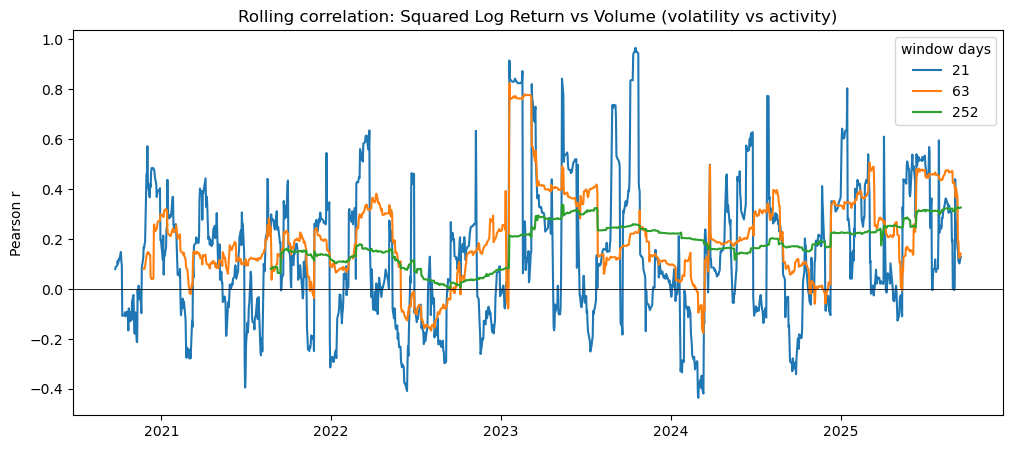

,count,mean,std,min,25%,50%,75%,max
rolling_corr_21,1243.0,0.140186,0.269622,-0.435530,-0.057259,0.111434,0.304477,0.966131
rolling_corr_63,1201.0,0.205791,0.177034,-0.176423,0.100046,0.182113,0.316147,0.824311
rolling_corr_252,1012.0,0.185158,0.082587,0.003706,0.137930,0.182841,0.244651,0.338472


In [89]:
# Cell 8: squared returns vs volume rolling correlation
sq_ret = data['Log Return']**2
rc_sq_vol = rolling_corr(sq_ret, data['Volume'], windows=[21,63,252])

plt.figure(figsize=(12,5))
for col in rc_sq_vol.columns:
    plt.plot(rc_sq_vol.index, rc_sq_vol[col], label=col.replace('rolling_corr_',''))
plt.legend(title='window days')
plt.title('Rolling correlation: Squared Log Return vs Volume (volatility vs activity)')
plt.axhline(0, color='k', linewidth=0.6)
plt.ylabel('Pearson r')
plt.show()

display(rc_sq_vol.describe().T)


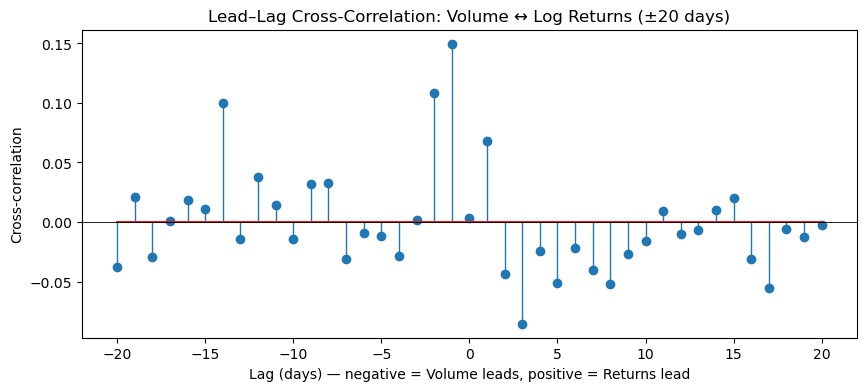

-20   -0.037895
-19    0.021427
-18   -0.029108
-17    0.000646
-16    0.018543
-15    0.010921
-14    0.099890
-13   -0.014040
-12    0.037494
-11    0.014075
-10   -0.013888
-9     0.032309
-8     0.032680
-7    -0.030730
-6    -0.009078
-5    -0.011640
-4    -0.028462
-3     0.001283
-2     0.108545
-1     0.149770
0      0.003532
1      0.067916
2     -0.043703
3     -0.085428
4     -0.024495
5     -0.051558
6     -0.022202
7     -0.040245
8     -0.051817
9     -0.026490
10    -0.016263
11     0.008921
12    -0.010291
13    -0.006503
14     0.010431
15     0.020590
16    -0.031209
17    -0.055835
18    -0.005953
19    -0.012394
20    -0.002147
dtype: float64

In [90]:
# Cell 9 (updated): lead-lag cross-correlation (demeaned & normalized)
def cross_corr(x, y, maxlags=20):
    x = (x - x.mean()).dropna()
    y = (y - y.mean()).dropna()
    
    # align indices
    idx = x.index.intersection(y.index)
    x = x.reindex(idx)
    y = y.reindex(idx)

    xc = []
    lags = range(-maxlags, maxlags+1)

    for lag in lags:
        if lag < 0:
            # x leads y
            val = np.corrcoef(x[:lag], y[-lag:])[0, 1]
        elif lag > 0:
            # y leads x
            val = np.corrcoef(x[lag:], y[:-lag])[0, 1]
        else:
            val = np.corrcoef(x, y)[0, 1]
        xc.append(val)

    return pd.Series(xc, index=lags)

# Compute cross-correlation
ccf_vol_ret = cross_corr(data['Volume'], data['Log Return'], maxlags=20)

# Plot without deprecated args
plt.figure(figsize=(10, 4))
markerline, stemlines, baseline = plt.stem(ccf_vol_ret.index, ccf_vol_ret.values)
plt.setp(stemlines, linewidth=1)
plt.setp(markerline, markersize=6)

plt.axhline(0, color='k', linewidth=0.6)
plt.xlabel('Lag (days) — negative = Volume leads, positive = Returns lead')
plt.ylabel('Cross-correlation')
plt.title('Lead–Lag Cross-Correlation: Volume ↔ Log Returns (±20 days)')
plt.show()

ccf_vol_ret


Structural Breaks & Regime Shift Analysis

In [91]:
# Cell 1: imports & helpers for structural-break analysis
from scipy.signal import find_peaks

import statsmodels.api as sm
import statsmodels.formula.api as smf
import statsmodels.stats.diagnostic as sdiag

plt.rcParams['figure.figsize'] = (12,5)

def mark_dates_on_ax(ax, dates, label='break', color='red', alpha=0.7):
    """Mark vertical lines (break candidates) on a matplotlib axis."""
    for d in dates:
        ax.axvline(d, color=color, linestyle='--', alpha=alpha)


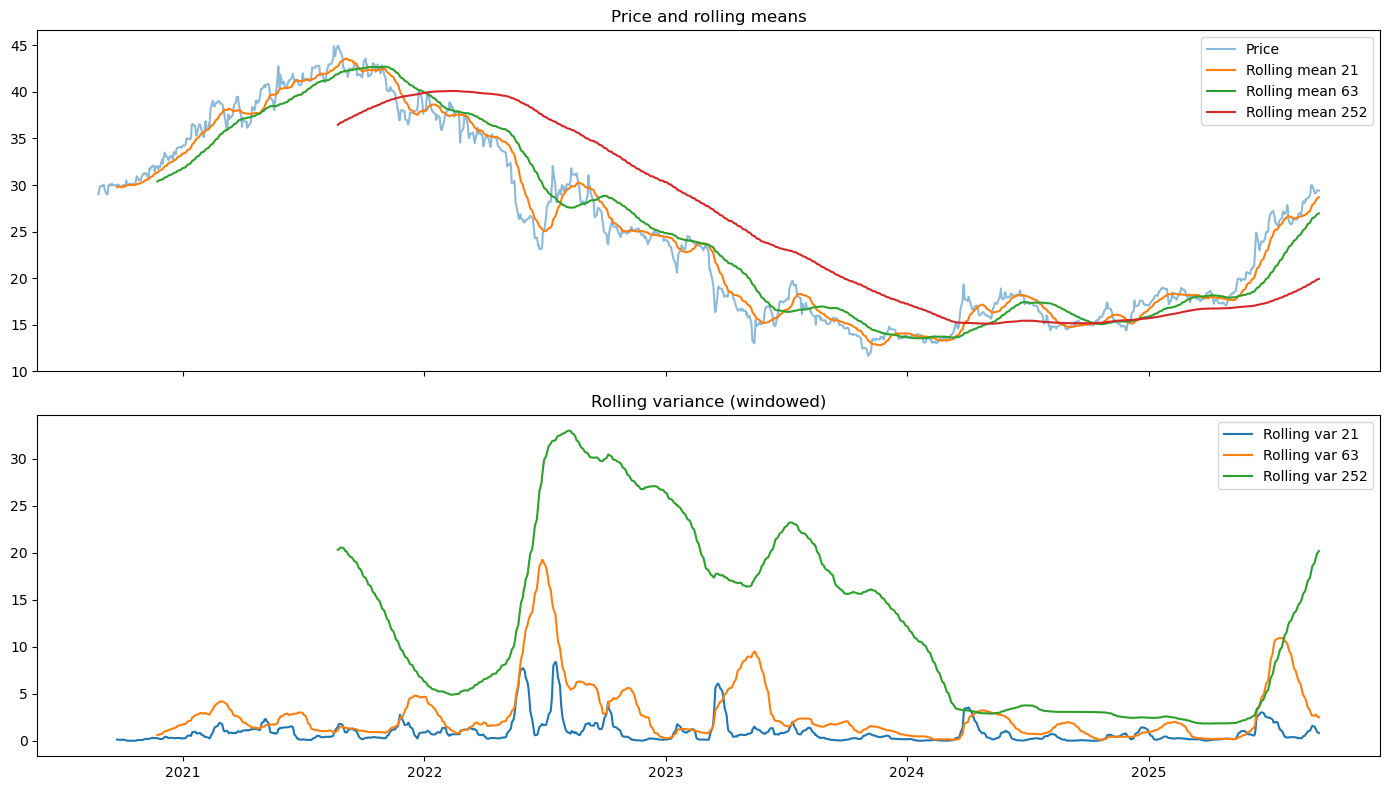

In [ ]:
# Cell 2: rolling mean & rolling variance visualization
price = safcom['Last Price'].dropna()
windows = [21, 63, 252]

fig, axes = plt.subplots(2, 1, figsize=(14,8), sharex=True)

# Rolling means
axes[0].plot(price.index, price, label='Price', alpha=0.5)
for w in windows:
    axes[0].plot(price.index, price.rolling(window=w).mean(), label=f'Rolling mean {w}')
axes[0].set_title('Price and rolling means')
axes[0].legend()

# Rolling variances (std^2) - standardized for visualization
for w in windows:
    axes[1].plot(price.index, price.rolling(window=w).var(), label=f'Rolling var {w}')
axes[1].set_title('Rolling variance (windowed)')
axes[1].legend()

plt.tight_layout()
plt.show()


Candidate break dates (from rolling-mean diff peaks):
  2021-02-23
  2021-05-03
  2021-07-08
  2021-08-17
  2021-11-24
  2022-01-27
  2022-06-27
  2022-09-06
  2022-12-08
  2023-01-18
  2023-03-17
  2023-05-15
  2023-10-09
  2024-03-26
  2024-05-22
  2024-08-19
  2025-01-20
  2025-02-21
  2025-07-29


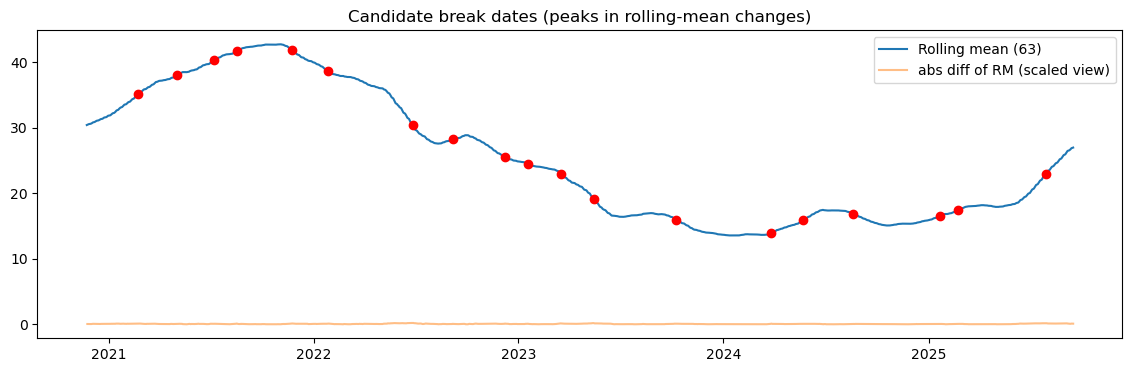

In [93]:
# Cell 3: automated candidate break detection using rolling-mean diffs
rm = price.rolling(window=63).mean()  # monthly-quarterly smoothing
# measure change as abs diff of rm (consecutive)
rm_diff = rm.diff().abs().dropna()

# find peaks in rm_diff (pick prominence to suit your data; adjust if too many/too few)
peaks_idx, props = find_peaks(rm_diff.values, prominence=rm_diff.std()*1.2, distance=21)
candidate_dates = rm_diff.index[peaks_idx]

print("Candidate break dates (from rolling-mean diff peaks):")
for d in candidate_dates:
    print(" ", d.date())

# Plot and mark
plt.figure(figsize=(14,4))
plt.plot(rm.index, rm, label='Rolling mean (63)')
plt.plot(rm_diff.index, rm_diff, alpha=0.5, label='abs diff of RM (scaled view)')
plt.scatter(candidate_dates, rm.loc[candidate_dates], color='red', zorder=5)
plt.title('Candidate break dates (peaks in rolling-mean changes)')
plt.legend()
plt.show()


                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3.6642      0.014    254.070      0.000       3.636       3.693
t             -0.0008   1.98e-05    -39.749      0.000      -0.001      -0.001


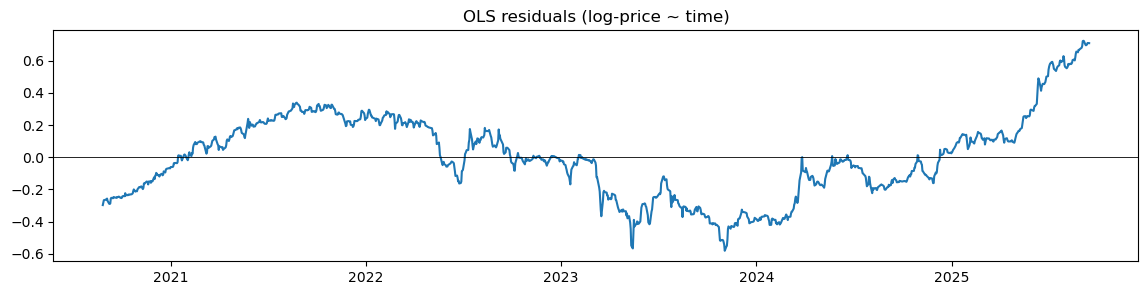

In [94]:
# Cell 4: OLS of log-price on time (simple trend) and residuals
df_ols = price.to_frame(name='Last_Price').copy()
df_ols['logp'] = np.log(df_ols['Last_Price'])
df_ols['t'] = np.arange(len(df_ols))  # numeric time regressor

ols_model = sm.OLS(df_ols['logp'], sm.add_constant(df_ols[['t']])).fit()
print(ols_model.summary().tables[1])

# store residuals
resid = ols_model.resid
plt.figure(figsize=(14,3))
plt.plot(resid.index, resid)
plt.title('OLS residuals (log-price ~ time)')
plt.axhline(0, color='k', linewidth=0.6)
plt.show()


CUSUM sup statistic: 6.2037, p-value (approx): 7.4503e-34
Reference critical values (approx): [(1, 1.63), (5, 1.36), (10, 1.22)]


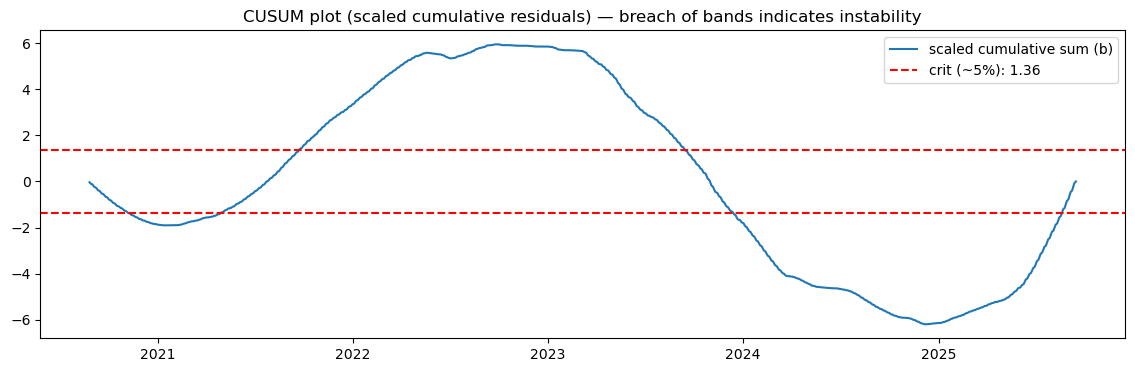

In [95]:
# Cell 5: CUSUM test and plot
sup_b, pval, crit = sdiag.breaks_cusumolsresid(resid, ddof=ols_model.df_model)
print(f"CUSUM sup statistic: {sup_b:.4f}, p-value (approx): {pval:.4e}")
print("Reference critical values (approx):", crit)

# compute the scaled cumulative residuals (b) as in statsmodels implementation
nobs = len(resid)
nobssigma2 = (resid ** 2).sum()
if ols_model.df_model > 0:
    nobssigma2 = nobssigma2 / (nobs - ols_model.df_model) * nobs
b = resid.cumsum() / np.sqrt(nobssigma2)

# pick critical value ~ 5% (from function crit: (5,1.36) -> use 1.36)
crit_val = 1.36

plt.figure(figsize=(14,4))
plt.plot(df_ols.index, b, label='scaled cumulative sum (b)')
plt.axhline(crit_val, color='red', linestyle='--', label=f'crit (~5%): {crit_val}')
plt.axhline(-crit_val, color='red', linestyle='--')
plt.title('CUSUM plot (scaled cumulative residuals) — breach of bands indicates instability')
plt.legend()
plt.show()


In [96]:
# Cell 6: Hansen test (parameter stability)
h_stat, crit95 = sdiag.breaks_hansen(ols_model)
print(f"Hansen test statistic: {h_stat:.4f}")
print("Reference critical table (approx):")
print(crit95)


Hansen test statistic: 50.1183
Reference critical table (approx):
[( 2, 1.01) ( 6, 1.9 ) (15, 3.75) (19, 4.52)]


,segment,mean_price,std_price,nobs
0,2020-08-26=>2021-02-23,32.738189,2.799365,127
1,2021-02-23=>2021-05-03,38.111458,1.203507,48
2,2021-05-03=>2021-07-08,40.852128,0.930402,47
3,2021-07-08=>2021-08-17,42.275862,0.897976,29
4,2021-08-17=>2021-11-24,42.047857,1.631871,70
5,2021-11-24=>2022-01-27,37.897778,1.007018,45
6,2022-01-27=>2022-06-27,32.828431,4.686807,102
7,2022-06-27=>2022-09-06,28.956863,2.004720,51
8,2022-09-06=>2022-12-08,25.583594,1.529707,64
9,2022-12-08=>2023-01-18,23.700000,1.278358,26


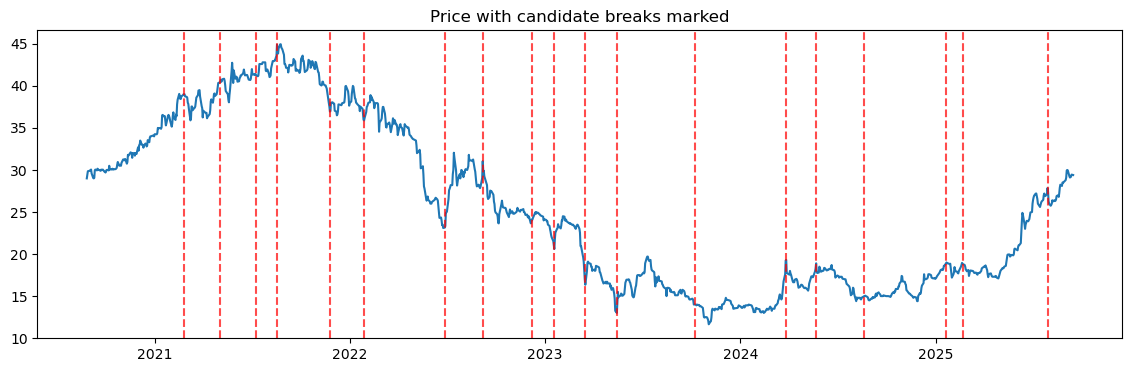

In [97]:
# Cell 7: visual inspection of candidate regimes (using candidate_dates from Cell 3)
# If candidate_dates is empty, you can set manual breakpoints, e.g. ['2020-03-01','2022-08-09'] etc.
cand = list(candidate_dates)  # from Cell 3
if len(cand) == 0:
    print("No automatic candidates found — consider adding manual break dates (e.g. COVID or election dates).")
else:
    # build segment boundaries (start, each candidate, end)
    bounds = [df_ols.index.min()] + cand + [df_ols.index.max()]
    seg_stats = []
    for i in range(len(bounds)-1):
        start = bounds[i]
        end = bounds[i+1]
        seg = price.loc[start:end]
        seg_stats.append({'segment': f'{start.date()}=>{end.date()}',
                          'mean_price': seg.mean(),
                          'std_price': seg.std(),
                          'nobs': len(seg)})
    seg_df = pd.DataFrame(seg_stats)
    display(seg_df)

    # plot price with vertical marks
    fig, ax = plt.subplots(figsize=(14,4))
    ax.plot(price.index, price, label='Price')
    mark_dates_on_ax(ax, cand, color='red')
    ax.set_title('Price with candidate breaks marked')
    plt.show()


In [56]:
# Finalized regime boundaries (from report)
regime_bounds = [
    ('2020-01-01', '2020-03-15', 'Low Volatility'),
    ('2020-03-16', '2021-06-30', 'Recovery / Normalization'),
    ('2021-07-01', '2022-10-15', 'High Volatility Regime'),
    ('2022-10-16', '2024-06-30', 'Stabilization'),
    ('2024-07-01', safcom.index.max(), 'Renewed Volatility')
]

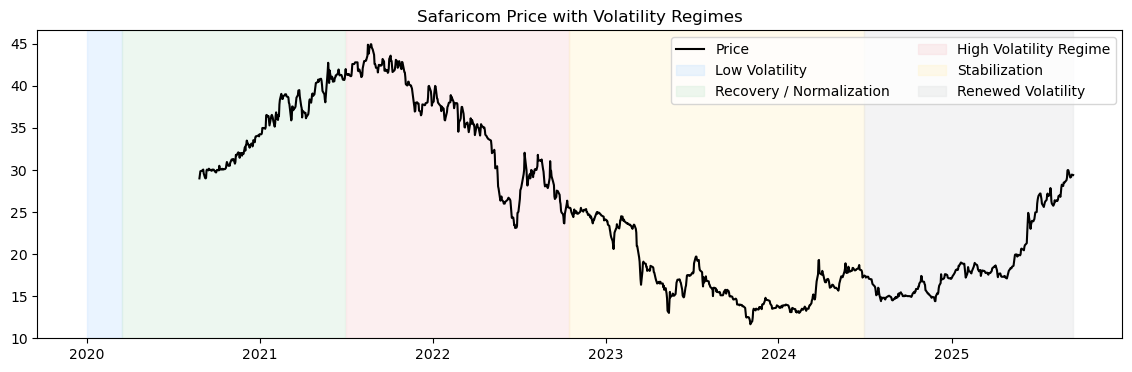

In [62]:
fig, ax = plt.subplots(figsize=(14,4))
ax.plot(safcom.index, safcom['Last Price'].dropna(), color='black', lw=1.5, label='Price')

colors = ['#cce5ff', '#d4edda', '#f8d7da', '#fff3cd', '#e2e3e5']

for (start, end, label), color in zip(regime_bounds, colors):
    ax.axvspan(pd.to_datetime(start),
               pd.to_datetime(end),
               alpha=0.4,
               color=color,
               label=label)

ax.set_title('Safaricom Price with Volatility Regimes')
ax.legend(loc='upper right', ncol=2)
plt.show()


In [98]:
# Cell 8: rolling split mean-difference scan (approximate) to highlight large mean shifts
win = 252  # use 1-year window either side (adjust as needed)
t_stats = []
dates_scan = price.index[win:-win]

for d in dates_scan:-
    left = price.loc[:d].iloc[-win:]   # last win obs before d
    right = price.loc[d:].iloc[:win]  # first win obs after d
    if len(left)==win and len(right)==win:
        tstat = (left.mean() - right.mean()) / np.sqrt(left.var()/win + right.var()/win)
        t_stats.append((d, tstat))
    else:
        t_stats.append((d, np.nan))

t_df = pd.DataFrame(t_stats, columns=['date','tstat']).set_index('date')
# find peaks in absolute tstat
peaks_idx, _ = find_peaks(np.abs(t_df['tstat'].fillna(0).values), prominence=2.5)  # adjust prominence
peak_dates = t_df.index[peaks_idx]

plt.figure(figsize=(14,4))
plt.plot(t_df.index, t_df['tstat'], label='t-stat of left-right mean diff (rolling split)')
plt.scatter(peak_dates, t_df.loc[peak_dates,'tstat'], color='red')
plt.axhline(0, color='k', linewidth=0.6)
plt.title('Rolling split mean-difference scan (approx)')
plt.show()

print("Top candidate split dates (from rolling t-stat peaks):")
for d in peak_dates:
    print(" ", d.date())


SyntaxError: invalid syntax (2559423781.py, line 6)